# The AI Asset Team
## Unlock a discovery. Protect the host. Replan when the compressor derates.

**One integrated NeqSim engineering study • advanced • synthetic offshore gas-condensate asset**

> “Can we accept 60 tonnes per hour from a new discovery without adding a compressor?
> Preserve both existing fields, explain the constraints, and show the value of each option.”

This notebook follows the complete decision: understand the plant, calculate the baseline,
discover bottlenecks, optimize operation, challenge the result, respond to a driver derating,
compare upgrades, and issue a traceable engineering brief. Every reported plant result is
calculated with NeqSim. The language model is responsible for selecting investigations and
explaining evidence; it cannot redefine the equipment limits or manufacture a feasible result.

**Run all** executes the complete numerical study and a labelled replay of the engineering
investigations selected during notebook development. An optional live OpenAI tool-calling loop
accepts a new user objective. It requires your own API credentials; the retained default run
does not claim that a live API conversation was executed.

[Example book](../examples_of_NeqSim_in_Colab.ipynb) ·
[Agentic API foundation](agentic_neqsim_workflow_demo.ipynb) ·
[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/agentic_asset_team_tieback_and_debottlenecking.ipynb)

## 01 · The engineering mission

The host receives **50 t/h from Field A** and **30 t/h from Field B**. A richer, higher-CO₂
discovery requests up to **60 t/h**. Two existing parallel compressors export at **110 bara**.
First solve the nominal study. Then reduce **Compressor 1 driver capacity by 15%**; Compressor 2
is unchanged. Existing-field feed rates remain fixed in every optimization and uncertainty run.

| Question | Calculation and evidence |
|---|---|
| What stops the discovery at existing settings? | Incremental flow sweep and explicit constraint margins |
| Can operating changes recover capacity? | Four-variable, multistart constrained SLSQP with full NeqSim evaluations |
| Does the compressor physically reach export pressure? | Seven-speed head/efficiency maps, surge, stonewall, speed and pressure checks |
| Are the attractive results numerically valid? | Whole-process mass, component and enthalpy balances; fresh reconstruction |
| What changes after the derating? | Fixed-setting capacity, old recommendation retest, load redistribution and reoptimization |
| What survives uncertainty? | Latin-hypercube full-process simulations and independent holdout sampling |
| Which modification has value? | Driver, cooler and combined packages; five-year incremental cash flow and resource scenarios |
| What is genuinely agentic? | Bounded tool selection, evidence inspection, replanning, and an enforced final verification |

**Tools and their roles:** NeqSim/JPype owns thermodynamics and equipment; SciPy owns numerical
search and sampling; pandas owns evidence tables; Matplotlib owns retained scientific figures;
Plotly supplies interactive exploration; JSON Schema guards agent calls. A compact direct
Responses API adapter avoids hiding the engineering tools inside a large orchestration framework.

## 02 · Reproducible runtime and provenance

The source reference below was current `equinor/neqsim` master when this study was built. It is
pinned so future runs can reproduce the same Java source. A clean Colab run fetches and builds
that commit before starting the JVM. `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` can reuse a
matching local source build, with commit, digest and class-location assertions retained.

The first run needs Java 17, Git and network access for dependencies. Source compilation can
take several minutes. Subsequent calculations use one JVM and fresh flowsheets, not a new JVM
per scenario. The notebook records actual timings rather than promising a universal runtime.

In [1]:
import hashlib
import importlib.util
import json
import os
import platform
import shutil
import subprocess
import sys
import time
from importlib.metadata import version
from pathlib import Path

NEQSIM_SOURCE_REF = "5eb26ebad6e180b3756248237ecc33129ec071f4"
required = ["neqsim==3.20.0", "numpy", "pandas", "scipy", "matplotlib", "plotly", "jsonschema"]
missing = []
for spec in required:
    package = spec.split("==")[0]
    if importlib.util.find_spec(package) is None:
        missing.append(spec)
    elif "==" in spec and version(package) != spec.split("==")[1]:
        missing.append(spec)
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)

source_override = os.environ.get("NEQSIM_SOURCE_ROOT")
source_root = Path(source_override or "neqsim-asset-source").resolve()
if not source_override:
    if not (source_root / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--filter=blob:none",
                "--no-checkout",
                "https://github.com/equinor/neqsim.git",
                str(source_root),
            ],
            check=True,
        )
    subprocess.run(["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=source_root, check=True)
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_REF], cwd=source_root, check=True
    )
    wrapper = "mvnw.cmd" if os.name == "nt" else "./mvnw"
    subprocess.run(
        [wrapper, "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package"],
        cwd=source_root,
        check=True,
    )

source_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
).strip()
assert source_commit == NEQSIM_SOURCE_REF, "Source override must match the pinned commit."
source_jar = Path(
    os.environ.get("NEQSIM_SOURCE_JAR", str(source_root / "target/neqsim-3.20.0.jar"))
).resolve()
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype

if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime so the source JAR is loaded before NeqSim imports.")
jpype.addClassPath(str(source_jar))
from neqsim.neqsimpython import init_jvm

init_jvm()
from neqsim import jneqsim as ns

runtime_class = jpype.JClass(
    "neqsim.process.equipment.compressor.CompressorOperatingPointResult"
)
loaded_from = str(runtime_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.as_uri() in loaded_from.replace("file:/", "file:///", 1)
PROVENANCE = {
    "source_repository": "equinor/neqsim",
    "source_commit": source_commit,
    "jar_sha256": jar_sha256,
    "loaded_from": loaded_from,
    "python": platform.python_version(),
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "packages": {
        name: version(name)
        for name in ["neqsim", "numpy", "pandas", "scipy", "matplotlib", "plotly", "jsonschema"]
    },
}
print(json.dumps(PROVENANCE, indent=2))


{
  "source_repository": "equinor/neqsim",
  "source_commit": "5eb26ebad6e180b3756248237ecc33129ec071f4",
  "jar_sha256": "43c82351ec1f2b164492dcfc9f168cfb10c66ca5f8932b0d1db2101971fe07e8",
  "loaded_from": "file:/workspace/scratch/2a5d9ded405b/core/target/neqsim-3.20.0.jar",
  "python": "3.12.14",
  "java": "17.0.20",
  "packages": {
    "neqsim": "3.20.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "scipy": "1.18.1",
    "matplotlib": "3.11.2",
    "plotly": "7.0.0",
    "jsonschema": "4.26.0"
  }
}


In [2]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Polygon
from IPython.display import HTML, Image, display
from scipy.optimize import minimize
from scipy.stats import qmc
import plotly.graph_objects as go
import jsonschema

OUTPUT = Path("asset_team_outputs")
OUTPUT.mkdir(exist_ok=True)
COLORS = {
    "navy": "#15334A",
    "teal": "#007F86",
    "gold": "#D69222",
    "red": "#BA4938",
    "blue": "#417CB8",
    "gray": "#6B7B8B",
}
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": COLORS["navy"],
        "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
    }
)
FIGURES = []


def show_figure(figure, name):
    figure.tight_layout()
    path = OUTPUT / (name + ".png")
    figure.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(figure)
    FIGURES.append(path)
    display(Image(filename=str(path)))


def show_table(frame, decimals=3):
    display(HTML(frame.round(decimals).to_html(index=False, border=0)))


display(HTML("""<div style='background:#15334A;color:white;padding:30px;border-radius:14px'>
<div style='color:#62D9CE;font-size:15px'>NEQSIM · ENGINEERING INTELLIGENCE</div>
<h1 style='color:white;margin:12px 0'>A discovery meets a constrained host</h1>
<p style='font-size:18px'>Three feeds. Two compressor trains. One auditable decision.</p>
<p>Discover → calculate → challenge → replan → verify</p></div>"""))


## 03 · Design basis, units and limits

All compositions are synthetic **mole fractions**. The model uses **SRK, classic mixing rules,
and multiphase stability checking**. PR supplies a separate model-form sensitivity later.
No heavy-end characterization or laboratory calibration is implied. Water and H₂S are excluded:
these are conditioned, sweet hydrocarbon feeds with CO₂. Dehydration, hydrates, corrosion,
relief design and transient anti-surge protection are outside this host-capacity screen.

The three source streams are at 45 °C and 80/75/90 bara. Each passes through its own isenthalpic
choke to the common manifold pressure. An inlet cooler sets the separator temperature.
Gas splits between two parallel compressor–aftercooler–scrubber trains; gas recombines at
110 bara. All three liquid outlets remain separate mass-balance products.

| Fixed assumption | Value | Ownership |
|---|---:|---|
| Host feeds A / B | 50,000 / 30,000 kg/h | Protected in every scenario |
| Discovery nomination ceiling | 60,000 kg/h | Commercial scenario, not equipment capacity |
| Manifold pressure bounds | 48–64 bara | Screening control range; well deliverability also checked |
| Separator temperature bounds | 22–32 °C | Utility temperature assumed 16 °C; no refrigeration model |
| Train 1 gas allocation | 35–65% | The remainder enters Train 2 |
| Compressor driver limits | 1,450 kW each | Explicit synthetic shaft limits |
| Compressor 1 derating | 0.85 × driver limit | Surprise scenario only |
| Aftercooler limits | 2,800 kW each | Positive heat removal |
| Inlet cooler limit | 1,800 kW | Positive heat removal |
| Separator gas / total liquid limits | 2,450 actual m³/h / 24,000 kg/h | Screening capacity assumptions |
| Compressor discharge temperature | ≤105 °C | Synthetic operating limit |
| Surge / stonewall distance | ≥10% / ≥5% | Defined by NeqSim operating-point output |
| Export CO₂ / Wobbe limits | ≤3.3 mol% / 48–57 MJ/Sm³ | Hypothetical contract; not a Gassco specification |

The unit **Sm³** is referenced to 15 °C and 1.01325 bara. ISO 6976 energy and volume reference
temperatures are both set to 15 °C. Compressor-map flow is **actual suction m³/h**. Never put
standard volume on an actual-volume compressor curve.

In [3]:
Stream = ns.process.equipment.stream.Stream
Valve = ns.process.equipment.valve.ThrottlingValve
Mixer = ns.process.equipment.mixer.Mixer
Cooler = ns.process.equipment.heatexchanger.Cooler
Separator = ns.process.equipment.separator.Separator
Splitter = ns.process.equipment.splitter.Splitter
Compressor = ns.process.equipment.compressor.Compressor
ProcessSystem = ns.process.processmodel.ProcessSystem
COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "n-butane",
    "n-pentane",
    "n-hexane",
]
COMPOSITIONS = [
    [0.01, 0.015, 0.825, 0.075, 0.045, 0.020, 0.007, 0.003],
    [0.01, 0.020, 0.780, 0.090, 0.055, 0.030, 0.010, 0.005],
    [0.01, 0.055, 0.725, 0.100, 0.060, 0.030, 0.015, 0.005],
]


Component,Host A,Host B,Discovery
nitrogen,0.010,0.010,0.010
CO2,0.015,0.020,0.055
methane,0.825,0.780,0.725
ethane,0.075,0.090,0.100
propane,0.045,0.055,0.060
n-butane,0.020,0.030,0.030
n-pentane,0.007,0.010,0.015
n-hexane,0.003,0.005,0.005


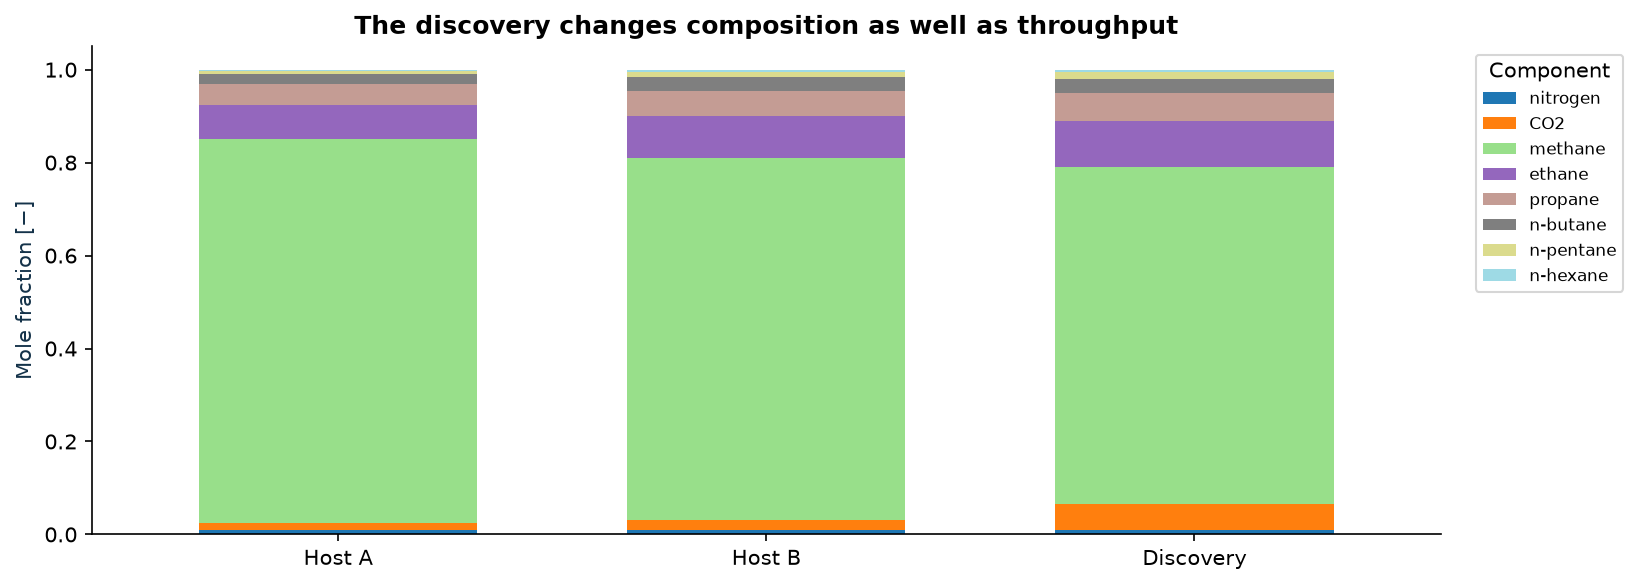

In [4]:
composition_table = pd.DataFrame(
    COMPOSITIONS, columns=COMPONENTS, index=["Host A", "Host B", "Discovery"]
).T
assert np.allclose(composition_table.sum().to_numpy(), 1.0)
show_table(composition_table.reset_index(names="Component"), 4)
figure, axis = plt.subplots(figsize=(11, 4))
composition_table.T.plot.bar(stacked=True, ax=axis, colormap="tab20", width=0.65)
axis.set(
    ylabel="Mole fraction [−]", title="The discovery changes composition as well as throughput"
)
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
show_figure(figure, "01_feed_composition")


## 04 · The physics behind the decision

NeqSim solves phase equilibrium and enthalpy changes; the optimizer never substitutes a
regression model for the final physics calculation. Phase equilibrium requires equal component
fugacity between coexisting phases:

$$f_i^{g}(T,p,\mathbf{y})=f_i^{l}(T,p,\mathbf{x})$$

Here $f_i$ is component fugacity, $T$ temperature, $p$ pressure, and $\mathbf{x}$ and
$\mathbf{y}$ liquid and gas composition. Cooling changes the gas mass entering the compressor
and shifts the mixture properties on which compressor head and power depend.

$$\dot W=\dot m_g(h_{out}-h_{in})$$

$$\dot Q=\dot m(h_{out}-h_{in})$$

Specific enthalpy $h$ is in J/kg and mass flow $\dot m$ in kg/s, giving W for heat and shaft
work. Heat removal is negative in the NeqSim cooler; plots report positive heat removed.
The entire plant is checked against:

$$\sum \dot m_{in}=\sum \dot m_{out}$$

$$\sum \dot n_{i,in}=\sum \dot n_{i,out}$$

$$\sum \dot m_{out}h_{out}-\sum \dot m_{in}h_{in}=\dot W+\dot Q$$

The boundary includes all feeds, gas export and all liquid products. It does not count
internal separator, splitter or mixer streams twice.

### Preventing free capacity from an unrealistic pressure increase

We use a transparent reduced gas-deliverability screen, calibrated at 45 bara:

$$q_{max,j}(p)=q_{45,j}\sqrt{\frac{p_{r,j}^{2}-p^2}{p_{r,j}^{2}-45^2}}$$

The synthetic reservoir/source pressure $p_{r,j}$ and manifold pressure $p$ are in bara;
$q_{45,j}$ is 70,000 / 42,000 / 80,000 kg/h for A / B / discovery. The exponent 0.5 is an
assumption, not a fitted well test. This reduced relation omits tubing, pipeline losses and
rate-dependent temperature. A project study must replace it with qualified well/SURF models.
Nevertheless it enforces the essential coupling: higher host pressure reduces deliverability.

In [5]:
def build(
    tie=30000.0,
    pressure=55.0,
    temperature=30.0,
    split=0.5,
    efficiency=0.78,
    co2_delta=0.0,
    maps=None,
    eos="SRK",
    source_pressure_drop=0.0,
):
    process = ProcessSystem()
    feeds, valves, compressors, coolers, separators = [], [], [], [], []
    for i, rate in enumerate([50000.0, 30000.0, tie]):
        if rate == 0:
            continue
        cls = ns.thermo.system.SystemSrkEos if eos == "SRK" else ns.thermo.system.SystemPrEos
        fluid = cls(318.15, [80.0, 75.0, 90.0][i] - source_pressure_drop)
        composition = list(COMPOSITIONS[i])
        if i == 2:
            composition[1] += co2_delta
            composition[2] -= co2_delta
        for component, fraction in zip(COMPONENTS, composition):
            fluid.addComponent(component, fraction)
        fluid.setMixingRule("classic")
        fluid.setMultiPhaseCheck(True)
        feed = Stream(["Host A", "Host B", "Discovery"][i], fluid)
        feed.setFlowRate(rate, "kg/hr")
        valve = Valve("Choke " + str(i), feed)
        valve.setOutletPressure(pressure, "bara")
        process.add(feed)
        process.add(valve)
        feeds.append(feed)
        valves.append(valve)
    mixer = Mixer("Inlet manifold")
    for valve in valves:
        mixer.addStream(valve.getOutletStream())
    process.add(mixer)
    cooler = Cooler("Inlet cooler", mixer.getOutletStream())
    cooler.setOutTemperature(temperature + 273.15)
    process.add(cooler)
    coolers.append(cooler)
    separator = Separator("Inlet separator", cooler.getOutletStream())
    process.add(separator)
    separators.append(separator)
    splitter = Splitter("Gas allocation", separator.getGasOutStream(), 2)
    splitter.setSplitFactors([split, 1 - split])
    process.add(splitter)
    gas_mixer = Mixer("Export manifold")
    for i in range(2):
        compressor = Compressor("Compressor " + str(i + 1), splitter.getSplitStream(i))
        compressor.setOutletPressure(110.0, "bara")
        compressor.setUsePolytropicCalc(True)
        compressor.setPolytropicEfficiency(efficiency)
        if maps is not None:
            compressor.setCompressorChart(copy_chart(maps[i]))
            compressor.setMinimumSpeed(float(maps[i].getMinSpeedCurve()))
            compressor.setMaximumSpeed(float(maps[i].getMaxSpeedCurve()))
            compressor.setLimitSpeed(True)
            compressor.setSolveSpeed(True)
        process.add(compressor)
        compressors.append(compressor)
        ac = Cooler("Aftercooler " + str(i + 1), compressor.getOutletStream())
        ac.setOutTemperature(303.15)
        process.add(ac)
        coolers.append(ac)
        scrubber = Separator("Export scrubber " + str(i + 1), ac.getOutletStream())
        process.add(scrubber)
        separators.append(scrubber)
        gas_mixer.addStream(scrubber.getGasOutStream())
    process.add(gas_mixer)
    process.run()
    return dict(
        process=process,
        feeds=feeds,
        valves=valves,
        compressors=compressors,
        coolers=coolers,
        separators=separators,
        export=gas_mixer.getOutletStream(),
        splitter=splitter,
    )


## 05 · Compressor maps: fixed equipment, changing operating points

We first solve a 30 t/h tie-back reference at 55 bara, 30 °C and equal load allocation with
78% assumed polytropic efficiency. `CompressorChartGenerator` creates seven speed curves around
that reference. These are **synthetic teaching maps**, not vendor performance data. They remain
fixed for the whole study; a new map is never generated around an attractive candidate.

Each candidate solves compressor speed to meet the export-pressure target, with bounds on map
speed. Feasibility uses actual attained pressure, speed, surge/stonewall distance, duty and power.
The generic native capacity defaults are not treated as approved plant limits: the explicit
design-basis policy supplies those limits.

In [6]:
design = build()
MAPS = []
for compressor in design["compressors"]:
    generator = ns.process.equipment.compressor.CompressorChartGenerator(compressor)
    generator.setChartType("interpolate and extrapolate")
    MAPS.append(generator.generateCompressorChart("normal curves", 7))


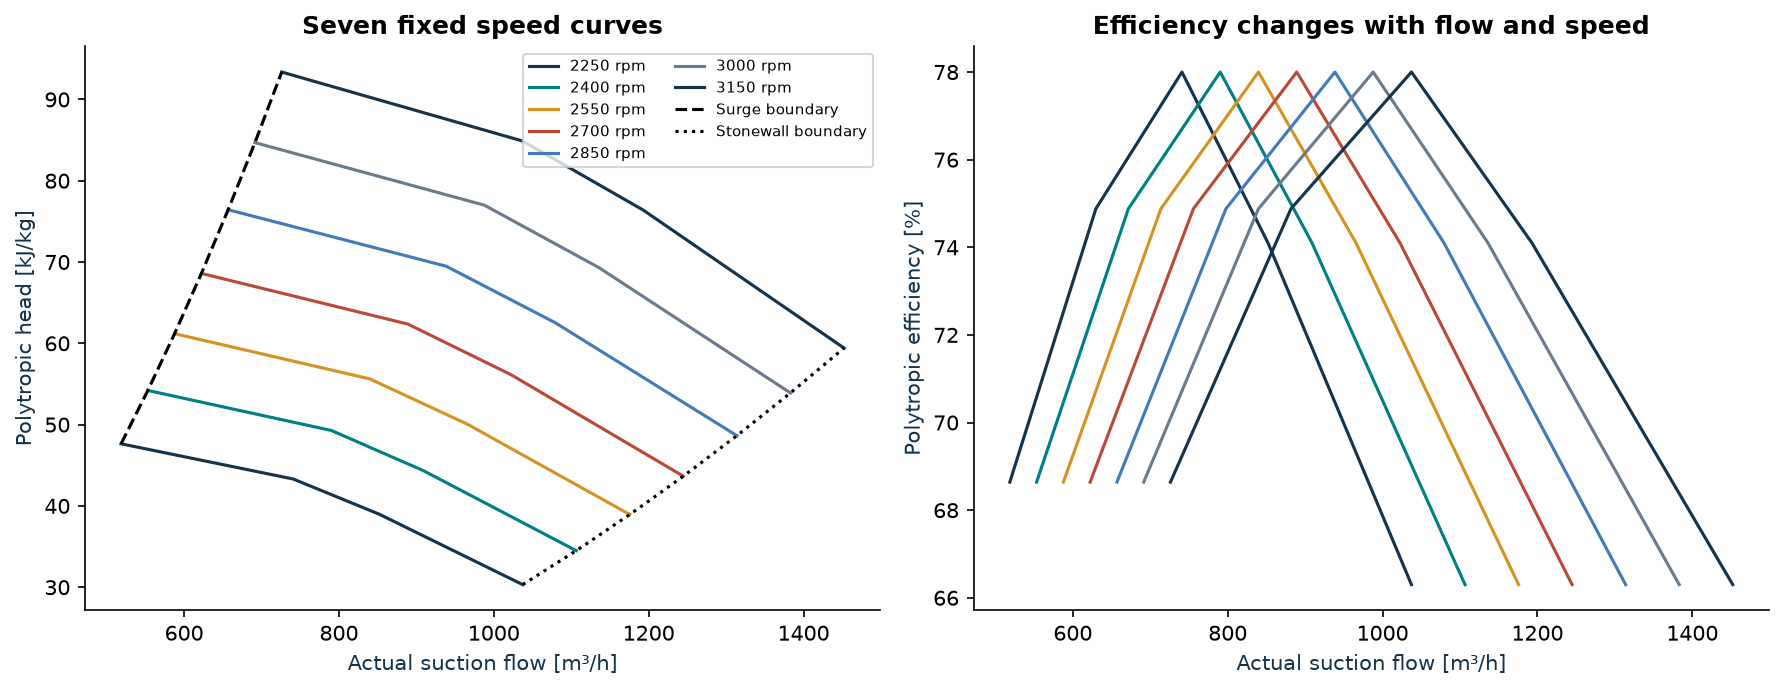

speed_rpm,flow_min,flow_max,head_max,efficiency_max
2250.0,518.653,1037.305,47.637,78.0
2400.0,553.229,1106.459,54.201,78.0
2550.0,587.806,1175.613,61.187,78.0
2700.0,622.383,1244.766,68.598,78.0
2850.0,656.960,1313.920,76.431,78.0
3000.0,691.537,1383.074,84.689,78.0
3150.0,726.114,1452.227,93.369,78.0


In [7]:
def copy_chart(chart):
    # Java serialization is not required: reconstruct the map from its immutable arrays.
    copied = chart.getClass().getDeclaredConstructor().newInstance()
    copied.setCurves(
        [float(design["compressors"][0].getInletStream().getFluid().getMolarMass("kg/mol"))],
        chart.getSpeeds(),
        chart.getFlows(),
        chart.getHeads(),
        chart.getPolytropicEfficiencies(),
    )
    copied.setHeadUnit("kJ/kg")
    copied.getSurgeCurve().setCurve(
        [0.0],
        [float(row[0]) for row in chart.getFlows()],
        [float(row[0]) for row in chart.getHeads()],
    )
    copied.getStoneWallCurve().setCurve(
        [0.0],
        [float(row[-1]) for row in chart.getFlows()],
        [float(row[-1]) for row in chart.getHeads()],
    )
    return copied


map_rows = []
for index, speed in enumerate(MAPS[0].getSpeeds()):
    for point, flow in enumerate(MAPS[0].getFlows()[index]):
        map_rows.append(
            {
                "speed_rpm": float(speed),
                "flow_m3_h": float(flow),
                "head_kJ_kg": float(MAPS[0].getHeads()[index][point]),
                "efficiency_pct": float(MAPS[0].getPolytropicEfficiencies()[index][point]),
            }
        )
map_frame = pd.DataFrame(map_rows)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for speed, group in map_frame.groupby("speed_rpm"):
    axes[0].plot(group.flow_m3_h, group.head_kJ_kg, label=f"{speed:.0f} rpm")
    axes[1].plot(group.flow_m3_h, group.efficiency_pct)
axes[0].set(
    xlabel="Actual suction flow [m³/h]",
    ylabel="Polytropic head [kJ/kg]",
    title="Seven fixed speed curves",
)
axes[1].set(
    xlabel="Actual suction flow [m³/h]",
    ylabel="Polytropic efficiency [%]",
    title="Efficiency changes with flow and speed",
)
for endpoint, label, linestyle in [
    (0, "Surge boundary", "--"),
    (-1, "Stonewall boundary", ":"),
]:
    axes[0].plot(
        [float(row[endpoint]) for row in MAPS[0].getFlows()],
        [float(row[endpoint]) for row in MAPS[0].getHeads()],
        color="black",
        linestyle=linestyle,
        linewidth=1.5,
        label=label,
    )
axes[0].legend(fontsize=7, ncol=2)
show_figure(figure, "02_compressor_maps")
show_table(
    map_frame.groupby("speed_rpm")
    .agg(
        flow_min=("flow_m3_h", "min"),
        flow_max=("flow_m3_h", "max"),
        head_max=("head_kJ_kg", "max"),
        efficiency_max=("efficiency_pct", "max"),
    )
    .reset_index()
)


## 06 · A bounded simulator with independent physical audits

Each evaluation creates a fresh `ProcessSystem` and records a unique simulation ID. The audit
thresholds are relative errors of **10⁻⁶ for mass/components** and **10⁻⁵ for energy**.
These checks are separate from operating margins. An operating margin of zero is a nominal
boundary, not evidence of robustness. The small feasibility tolerance of 10⁻⁷ is solely for
floating-point comparisons.

CO₂ and Wobbe values are calculated from the final mixed export gas. Each compressor's
enthalpy rise is included in the whole-system energy audit. A candidate that needs the inlet
cooler to add heat is rejected because no heater is included in the flowsheet.

In [8]:
def audit(model):
    feeds = model["feeds"]
    products = [model["export"]] + [s.getLiquidOutStream() for s in model["separators"]]
    mass_in = sum(float(s.getFlowRate("kg/hr")) for s in feeds)
    mass_out = sum(float(s.getFlowRate("kg/hr")) for s in products)
    component_errors = []
    for name in COMPONENTS:

        def molar(stream):
            return float(stream.getFlowRate("mole/sec")) * float(
                stream.getFluid().getComponent(name).getz()
            )

        mol_in = sum(molar(s) for s in feeds)
        mol_out = sum(molar(s) for s in products)
        component_errors.append(abs(mol_out - mol_in) / max(mol_in, 1e-12))

    def enthalpy(stream):
        return float(stream.getFlowRate("kg/sec")) * float(
            stream.getFluid().getEnthalpy("J/kg")
        )

    delta_h = sum(enthalpy(s) for s in products) - sum(enthalpy(s) for s in feeds)
    work = sum(float(c.getPower("W")) for c in model["compressors"])
    heat = sum(float(c.getDuty()) for c in model["coolers"])
    return dict(
        mass_error=abs(mass_out - mass_in) / mass_in,
        component_error=max(component_errors),
        energy_error=abs(delta_h - work - heat) / max(abs(work) + abs(heat), 1.0),
    )


COUNT = 0
CACHE = {}
HISTORY = []


def evaluate(
    x,
    derating=1.0,
    upgrade="none",
    co2_delta=0.0,
    ambient=0.0,
    eos="SRK",
    fresh=False,
    source_pressure_drop=0.0,
):
    global COUNT
    tie, pressure, temperature, split = map(float, x)
    key = (
        tie,
        pressure,
        temperature,
        split,
        derating,
        upgrade,
        co2_delta,
        ambient,
        eos,
        source_pressure_drop,
    )
    if not fresh and key in CACHE:
        return CACHE[key]
    start = time.perf_counter()
    model = build(
        tie=tie,
        pressure=pressure,
        temperature=temperature + ambient,
        split=split,
        maps=MAPS,
        co2_delta=co2_delta,
        eos=eos,
        source_pressure_drop=source_pressure_drop,
    )
    COUNT += 1
    errors = audit(model)
    points = [
        json.loads(str(c.getOperatingPointResult().toJson())) for c in model["compressors"]
    ]
    export = model["export"]
    quality = ns.standards.gasquality.Standard_ISO6976(export.getFluid(), 15.0, 15.0, "volume")
    quality.calculate()
    gcv = float(quality.getValue("SuperiorCalorificValue")) / 1000.0
    wobbe = float(quality.getValue("SuperiorWobbeIndex")) / 1000.0
    power = sum(p["powerKW"] for p in points)
    co2 = float(export.getFluid().getComponent("CO2").getz())
    cooling = [-float(c.getDuty()) / 1000 for c in model["coolers"]]
    limits = [1450.0 * derating, 1450.0]
    if upgrade in ["driver", "combined"]:
        limits[0] *= 1.20
        limits[1] *= 1.20
    cooling_limit = 2800.0 * (1.25 if upgrade in ["cooler", "combined"] else 1.0)
    margins = {}
    for i, p in enumerate(points):
        tag = str(i + 1)
        margins["driver_" + tag] = 1.0 - p["powerKW"] / limits[i]
        margins["surge_" + tag] = p["distanceToSurge"] - 0.10
        margins["stonewall_" + tag] = p["distanceToStonewall"] - 0.05
        margins["temperature_" + tag] = (105.0 - p["dischargeTemperatureC"]) / 105.0
        margins["pressure_" + tag] = 0.005 - abs(p["actualDischargePressureBara"] / 110.0 - 1.0)
        margins["speed_min_" + tag] = p["speedRpm"] / float(MAPS[i].getMinSpeedCurve()) - 1.0
        margins["speed_max_" + tag] = 1.0 - p["speedRpm"] / float(MAPS[i].getMaxSpeedCurve())
        margins["aftercooler_" + tag] = 1.0 - cooling[i + 1] / cooling_limit
    margins["inlet_cooling"] = 1.0 - cooling[0] / 1800.0
    margins["no_heating"] = min(cooling) / 1800.0
    margins["separator_gas"] = (
        1.0 - float(model["splitter"].getInletStream().getFlowRate("m3/hr")) / 2450.0
    )
    margins["separator_liquid"] = (
        1.0
        - sum(float(s.getLiquidOutStream().getFlowRate("kg/hr")) for s in model["separators"])
        / 24000.0
    )
    margins["CO2"] = 1.0 - co2 / 0.033
    margins["Wobbe_low"] = wobbe / 48.0 - 1.0
    margins["Wobbe_high"] = 1.0 - wobbe / 57.0
    for tag, pres, capacity, required in [
        ("A", 80.0, 70000.0, 50000.0),
        ("B", 75.0, 42000.0, 30000.0),
        ("tie", 90.0, 80000.0, tie),
    ]:
        reference_pressure = pres
        pres -= source_pressure_drop
        available = capacity * np.sqrt(
            max(pres**2 - pressure**2, 0) / (reference_pressure**2 - 45.0**2)
        )
        margins["deliverability_" + tag] = (available - required) / capacity
    margins["mass_audit"] = 1e-6 - errors["mass_error"]
    margins["component_audit"] = 1e-6 - errors["component_error"]
    margins["energy_audit"] = 1e-5 - errors["energy_error"]
    # Physical numerical tolerances are evaluated separately from operating margins.
    valid = all(v <= limit for v, limit in zip(errors.values(), [1e-6, 1e-6, 1e-5]))
    active = {
        k: v
        for k, v in margins.items()
        if not k.endswith("_audit") and not k.startswith("pressure_")
    }
    result = dict(
        host_A_kg_h=float(model["feeds"][0].getFlowRate("kg/hr")),
        host_B_kg_h=float(model["feeds"][1].getFlowRate("kg/hr")),
        tie_kg_h=tie,
        pressure_bara=pressure,
        temperature_C=temperature,
        split=split,
        derating=derating,
        upgrade=upgrade,
        power_kW=power,
        cooling_kW=sum(cooling),
        gas_kg_h=float(export.getFlowRate("kg/hr")),
        liquid_kg_h=sum(
            float(s.getLiquidOutStream().getFlowRate("kg/hr")) for s in model["separators"]
        ),
        gas_Sm3_h=float(export.getFlowRate("Sm3/hr")),
        gcv_MJ_Sm3=gcv,
        wobbe_MJ_Sm3=wobbe,
        co2_mol_pct=co2 * 100.0,
        margins=margins,
        points=points,
        **errors,
        feasible=bool(valid and min(margins.values()) >= -1e-7),
        limiting=min(active, key=active.get),
        elapsed_s=time.perf_counter() - start,
        simulation_id=f"SIM-{COUNT:05d}",
    )
    CACHE[key] = result
    HISTORY.append(result)
    return result


In [9]:
CONTROL_BOUNDS = [(0.0, 60000.0), (48.0, 64.0), (22.0, 32.0), (0.35, 0.65)]
raw_evaluate = evaluate
ACTIVE_SIMULATION_LIMIT = None


def evaluate(
    x,
    derating=1.0,
    upgrade="none",
    co2_delta=0.0,
    ambient=0.0,
    eos="SRK",
    fresh=False,
    source_pressure_drop=0.0,
):
    if len(x) != 4 or any(isinstance(value, bool) for value in x):
        raise ValueError("Four numerical controls are required.")
    if not all(math.isfinite(float(value)) for value in x):
        raise ValueError("Controls must be finite.")
    if not all(lo - 1e-8 <= value <= hi + 1e-8 for value, (lo, hi) in zip(x, CONTROL_BOUNDS)):
        raise ValueError("A control is outside the reviewed operating range.")
    if upgrade not in {"none", "driver", "cooler", "combined"} or eos not in {"SRK", "PR"}:
        raise ValueError("Unknown model or modification package.")
    if not (0.5 <= derating <= 1.2 and abs(co2_delta) <= 0.02 and abs(ambient) <= 3.0):
        raise ValueError("Disturbance outside the documented study envelope.")
    if ACTIVE_SIMULATION_LIMIT is not None and COUNT >= ACTIVE_SIMULATION_LIMIT:
        raise RuntimeError("Per-session simulation budget reached.")
    if not math.isfinite(source_pressure_drop) or not 0.0 <= source_pressure_drop <= 8.0:
        raise ValueError("Source-pressure decline outside the 0–8 bar scenario envelope.")
    result = raw_evaluate(
        x, derating, upgrade, co2_delta, ambient, eos, fresh, source_pressure_drop
    )
    if not all(math.isfinite(float(value)) for value in result["margins"].values()):
        raise ArithmeticError("Non-finite feasibility evidence.")
    result["co2_delta"] = co2_delta
    result["cooling_tracking_error_C"] = ambient
    result["eos"] = eos
    result["source_pressure_drop_bar"] = source_pressure_drop
    return result


def controls(result):
    return [result[key] for key in ["tie_kg_h", "pressure_bara", "temperature_C", "split"]]


def compact(result):
    keys = [
        "simulation_id",
        "tie_kg_h",
        "pressure_bara",
        "temperature_C",
        "split",
        "power_kW",
        "cooling_kW",
        "gas_kg_h",
        "liquid_kg_h",
        "co2_mol_pct",
        "wobbe_MJ_Sm3",
        "feasible",
        "limiting",
    ]
    return {key: result[key] for key in keys}


baseline = evaluate([0.0, 55.0, 30.0, 0.5])
nomination_at_old_settings = evaluate([60000.0, 55.0, 30.0, 0.5])
show_table(
    pd.DataFrame([compact(baseline), compact(nomination_at_old_settings)]).T.reset_index(
        names="Metric"
    )
)


Metric,0,1
simulation_id,SIM-00001,SIM-00002
tie_kg_h,0.0,60000.0
pressure_bara,55.0,55.0
temperature_C,30.0,30.0
split,0.5,0.5
power_kW,2384.809799,3863.108274
cooling_kW,4256.599576,6961.406448
gas_kg_h,80000.0,139136.552156
liquid_kg_h,0.0,863.447844
co2_mol_pct,1.679978,3.219218


## 07 · The host facility, with explicit product branches

The figure follows the calculated topology. A/B/discovery feeds pass through individual chokes
before mixing. The two compressors are in parallel. Three liquid products leave the balance
boundary; no oil outlet is incorrectly drawn in series with gas export. This is a process
overview, not a detailed P&ID or safeguarding design.

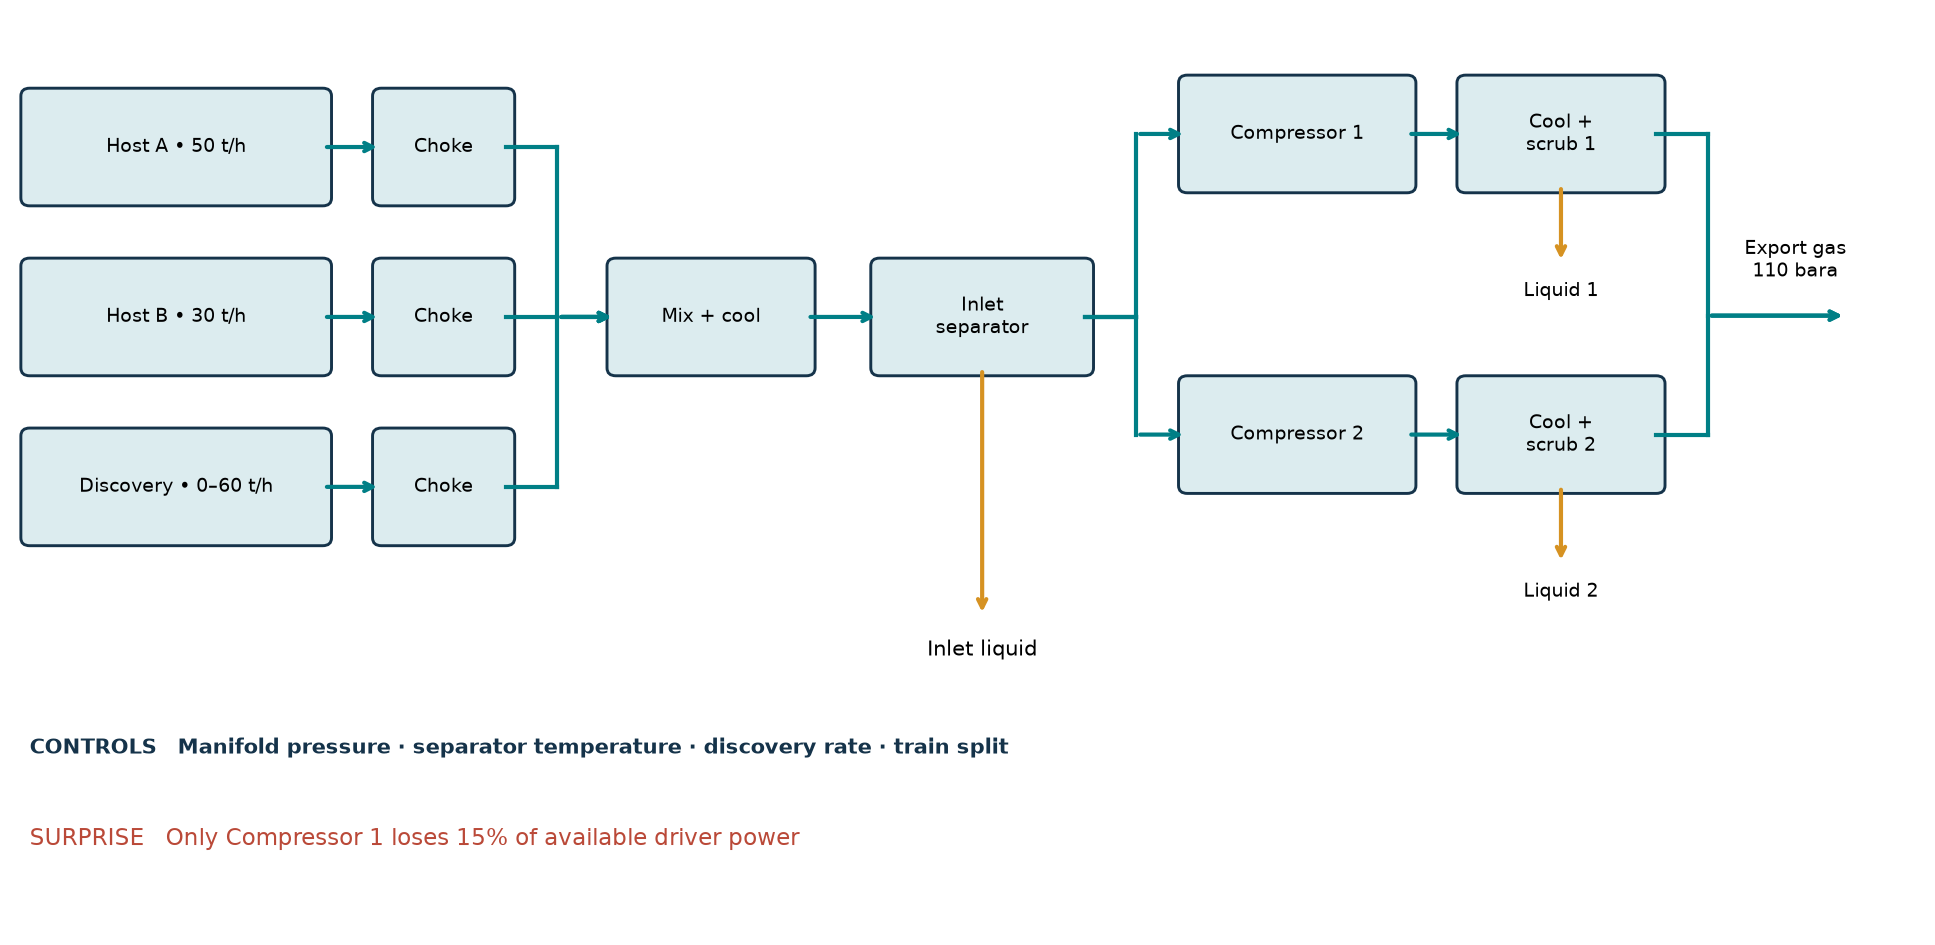

In [10]:
figure, axis = plt.subplots(figsize=(13, 6.4))
axis.set(xlim=(0, 13), ylim=(0, 7))
axis.axis("off")


def box(x, y, label, width=1.55, color="#DCECEF"):
    axis.add_patch(
        FancyBboxPatch(
            (x, y),
            width,
            0.78,
            boxstyle="round,pad=0.06",
            facecolor=color,
            edgecolor=COLORS["navy"],
            linewidth=1.4,
        )
    )
    axis.text(x + width / 2, y + 0.39, label, ha="center", va="center", fontsize=9)


def arrow(points, color=None):
    color = color or COLORS["teal"]
    for start, end in zip(points[:-2], points[1:-1]):
        axis.plot([start[0], end[0]], [start[1], end[1]], color=color, linewidth=2)
    axis.annotate(
        "",
        xy=points[-1],
        xytext=points[-2],
        arrowprops={"arrowstyle": "->", "color": color, "lw": 2},
    )


for y, name in [
    (5.6, "Host A • 50 t/h"),
    (4.3, "Host B • 30 t/h"),
    (3.0, "Discovery • 0–60 t/h"),
]:
    box(0.1, y, name, 2.0)
    box(2.5, y, "Choke", 0.85)
    arrow([(2.1, y + 0.39), (2.5, y + 0.39)])
    arrow([(3.35, y + 0.39), (3.7, y + 0.39), (3.7, 4.69), (4.1, 4.69)])
box(4.1, 4.3, "Mix + cool", 1.3)
box(5.9, 4.3, "Inlet\nseparator", 1.4)
arrow([(5.4, 4.69), (5.9, 4.69)])
for y, tag in [(5.7, "1"), (3.4, "2")]:
    arrow([(7.3, 4.69), (7.65, 4.69), (7.65, y + 0.39), (8.0, y + 0.39)])
    box(8.0, y, "Compressor " + tag, 1.5)
    box(9.9, y, "Cool +\nscrub " + tag, 1.3)
    arrow([(9.5, y + 0.39), (9.9, y + 0.39)])
    arrow([(11.2, y + 0.39), (11.55, y + 0.39), (11.55, 4.7), (12.5, 4.7)])
    arrow([(10.55, y), (10.55, y - 0.6)], COLORS["gold"])
    axis.text(10.55, y - 0.85, "Liquid " + tag, ha="center", fontsize=9)
arrow([(6.6, 4.3), (6.6, 2.4)], COLORS["gold"])
axis.text(6.6, 2.1, "Inlet liquid", ha="center")
axis.text(12.15, 5.0, "Export gas\n110 bara", ha="center", fontsize=9)
axis.text(
    0.1,
    1.35,
    "CONTROLS   Manifold pressure · separator temperature · discovery rate · train split",
    color=COLORS["navy"],
    weight="bold",
    fontsize=10,
)
axis.text(
    0.1,
    0.65,
    "SURPRISE   Only Compressor 1 loses 15% of available driver power",
    color=COLORS["red"],
    fontsize=11,
)
show_figure(figure, "03_asset_flowsheet")


## 08 · Baseline evidence and automated model discovery

The agent can inspect named units and unit-aware variable addresses through `ProcessAutomation`.
The task-specific tool facade later exposes only the reviewed controls and analyses. Access to
the complete Java object graph is useful for engineers but is not offered as arbitrary code
execution to the language model.

In [11]:
baseline_model = build(tie=0.0, maps=MAPS)
automation = baseline_model["process"].getAutomation()
discovered = []
for unit_name in automation.getUnitList():
    for variable in automation.getVariableList(unit_name):
        discovered.append(
            {
                "unit": str(unit_name),
                "address": str(variable.getAddress()),
                "unit_of_measure": str(variable.getDefaultUnit()),
            }
        )
variable_catalog = pd.DataFrame(discovered)
show_table(
    variable_catalog[variable_catalog.address.str.contains("power|pressure|temperature")].head(
        24
    )
)
print("Discovered variables:", len(variable_catalog))
show_table(
    pd.DataFrame(
        [
            {
                "check": key,
                "relative_error": value,
                "limit": 1e-5 if key == "energy_error" else 1e-6,
            }
            for key, value in audit(baseline_model).items()
        ]
    ),
    12,
)


Discovered variables: 153


unit,address,unit_of_measure
Host A,Host A.temperature,K
Host A,Host A.pressure,bara
Host A,Host A.temperature,K
Host A,Host A.pressure,bara
Choke 0,Choke 0.temperature,K
Choke 0,Choke 0.pressure,bara
Choke 0,Choke 0.outletStream.temperature,K
Choke 0,Choke 0.outletStream.pressure,bara
Host B,Host B.temperature,K
Host B,Host B.pressure,bara


check,relative_error,limit
mass_error,0.000000e+00,0.000001
component_error,0.000000e+00,0.000001
energy_error,1.000000e-12,0.000010


## 09 · How much tie-back fits at the original settings?

The capacity scan holds pressure at 55 bara, separator temperature at 30 °C and equal train
allocation. It performs a complete process simulation at every point. The highest feasible
sample is then refined locally by bisection. This refinement is confined to the observed
feasible-to-infeasible transition; it does not assume that all multiphase operating envelopes
are globally monotonic.

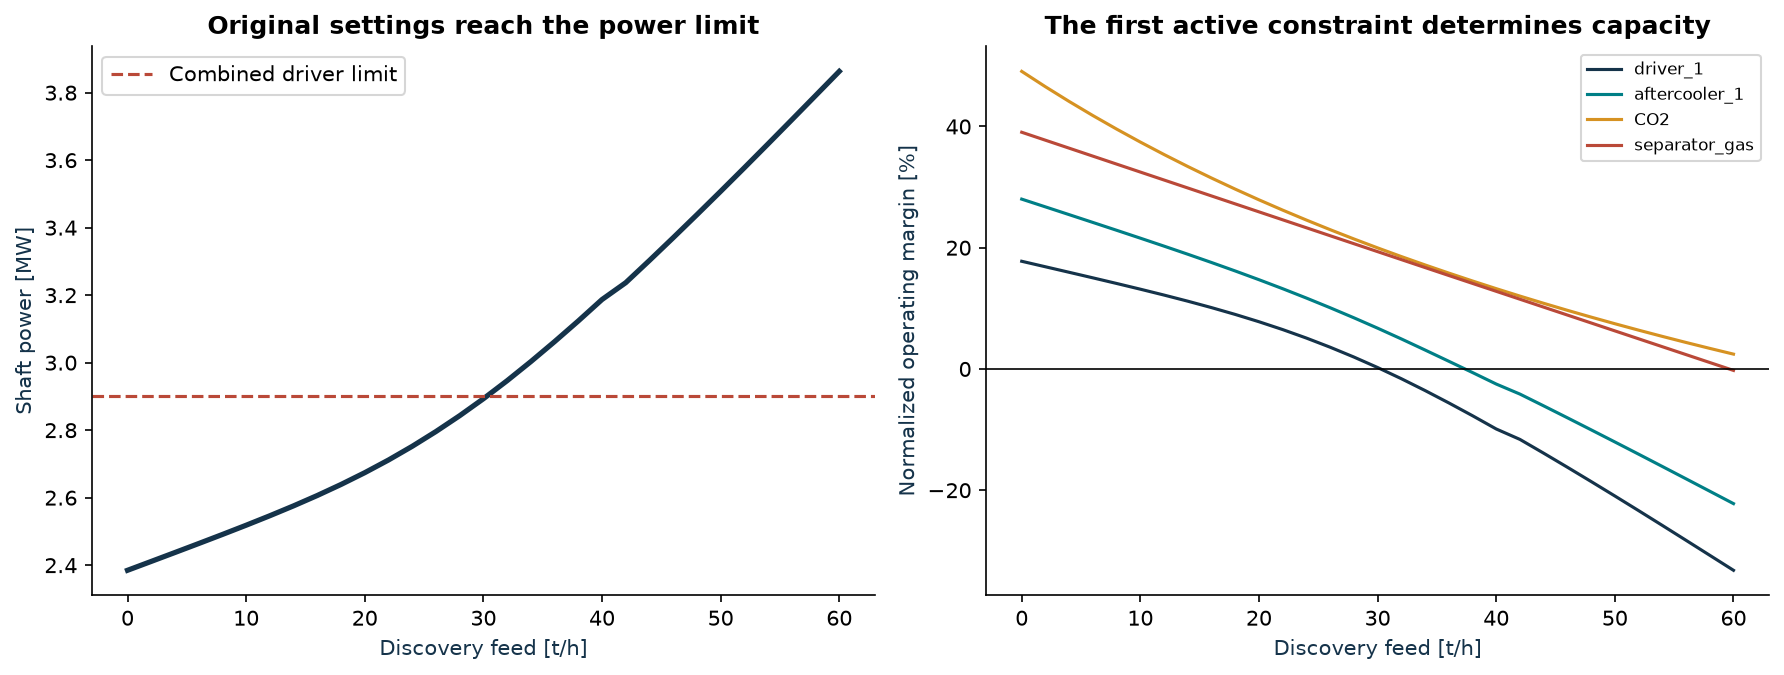

Metric,0
simulation_id,SIM-00049
tie_kg_h,30265.693665
pressure_bara,55.0
temperature_C,30.0
split,0.5
power_kW,2900.000269
cooling_kW,5378.935698
gas_kg_h,110265.693665
liquid_kg_h,0.0
co2_mol_pct,2.647287


In [12]:
def fixed_setting_capacity(derating=1.0):
    rows = [
        evaluate([float(rate), 55.0, 30.0, 0.5], derating=derating)
        for rate in np.linspace(0.0, 60000.0, 31)
    ]
    feasible = [row for row in rows if row["feasible"]]
    if not feasible:
        raise RuntimeError("Even the protected host baseline is infeasible.")
    best = max(feasible, key=lambda row: row["tie_kg_h"])
    upper = min(best["tie_kg_h"] + 2000.0, 60000.0)
    lower = best["tie_kg_h"]
    for iteration in range(18):
        middle = (lower + upper) / 2
        candidate = evaluate([middle, 55.0, 30.0, 0.5], derating=derating)
        if candidate["feasible"]:
            lower = middle
            best = candidate
        else:
            upper = middle
    return best, rows


fixed_nominal, sweep = fixed_setting_capacity()
sweep_frame = pd.DataFrame([compact(row) for row in sweep])
figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(sweep_frame.tie_kg_h / 1000, sweep_frame.power_kW / 1000, linewidth=2.5)
axes[0].axhline(2.9, color=COLORS["red"], linestyle="--", label="Combined driver limit")
axes[0].set(
    xlabel="Discovery feed [t/h]",
    ylabel="Shaft power [MW]",
    title="Original settings reach the power limit",
)
axes[0].legend()
for key in ["driver_1", "aftercooler_1", "CO2", "separator_gas"]:
    axes[1].plot(
        sweep_frame.tie_kg_h / 1000, [r["margins"][key] * 100 for r in sweep], label=key
    )
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Discovery feed [t/h]",
    ylabel="Normalized operating margin [%]",
    title="The first active constraint determines capacity",
)
axes[1].legend(fontsize=8)
show_figure(figure, "04_fixed_settings_capacity")
show_table(pd.DataFrame([compact(fixed_nominal)]).T.reset_index(names="Metric"))


## 10 · Joint optimization of pressure, cooling and train allocation

The decision vector is discovery rate, manifold pressure, separator temperature and Train 1
flow fraction. The rate is scaled by the 60 t/h nomination. SLSQP minimizes its negative:

$$\min_{q,p,T,a}\; -q/60000 \quad\text{subject to}\quad g_k(q,p,T,a)\geq0$$

Here $a$ is the gas fraction entering Train 1, and $g_k$ denotes every operating and
deliverability margin. Existing-field rates are fixed. Two starting points reduce dependence
on a single local start; they do not establish global optimality. Final candidates are rebuilt
and audited independently. Reaching 60 t/h proves that the entire requested nomination fits
the screened constraints, not that the equipment has no further capacity.

In [13]:
def optimize(derating=1.0, upgrade="none", margin=0.0, source_pressure_drop=0.0):
    def decode(y):
        return [y[0] * 60000.0, y[1], y[2], y[3]]

    def obj(y):
        return -y[0]

    def constraints(y):
        r = evaluate(
            decode(y),
            derating=derating,
            upgrade=upgrade,
            source_pressure_drop=source_pressure_drop,
        )
        return np.array(
            [
                v - (margin if k.startswith(("driver_", "aftercooler_", "CO2")) else 0.0)
                for k, v in r["margins"].items()
                if not k.endswith("_audit")
            ]
        )

    results = []
    for start in [[0.5, 55.0, 27.0, 0.5], [0.7, 60.0, 25.0, 0.45]]:
        opt = minimize(
            obj,
            start,
            method="SLSQP",
            bounds=[(0.0, 1.0), (48.0, 64.0), (22.0, 32.0), (0.35, 0.65)],
            constraints=[{"type": "ineq", "fun": constraints}],
            options={"maxiter": 55, "ftol": 2e-6, "eps": 1e-4},
        )
        r = evaluate(
            decode(opt.x),
            derating=derating,
            upgrade=upgrade,
            fresh=True,
            source_pressure_drop=source_pressure_drop,
        )
        r["optimizer_success"] = bool(opt.success)
        r["optimizer_message"] = str(opt.message)
        results.append(r)
    feasible = [r for r in results if r["feasible"]]
    return max(feasible, key=lambda r: r["tie_kg_h"]) if feasible else results[-1]


In [14]:
nominal_start = time.perf_counter()
nominal_calls = COUNT
nominal = optimize()
nominal_metrics = {
    "seconds": time.perf_counter() - nominal_start,
    "simulations": COUNT - nominal_calls,
}
assert nominal["feasible"]
show_table(
    pd.DataFrame([compact(fixed_nominal), compact(nominal)]).T.reset_index(names="Metric")
)
print("Optimizer:", nominal["optimizer_message"], nominal_metrics)


Optimizer: Optimization terminated successfully {'seconds': 7.3376886539990664, 'simulations': 102}


Metric,0,1
simulation_id,SIM-00049,SIM-00100
tie_kg_h,30265.693665,60000.0
pressure_bara,55.0,61.548885
temperature_C,30.0,23.66226
split,0.5,0.5
power_kW,2900.000269,2899.573625
cooling_kW,5378.935698,6093.364441
gas_kg_h,110265.693665,135399.622429
liquid_kg_h,0.0,4600.377571
co2_mol_pct,2.647287,3.232135


## 11 · The operating envelope explains the recommendation

This independent grid fixes the selected separator temperature and equal train allocation,
then varies pressure and discovery rate. The white outline separates screened feasible points.
High-pressure cases must still protect Field B deliverability. The grid tests the physical
interpretation around the optimizer result rather than trusting its success flag alone.

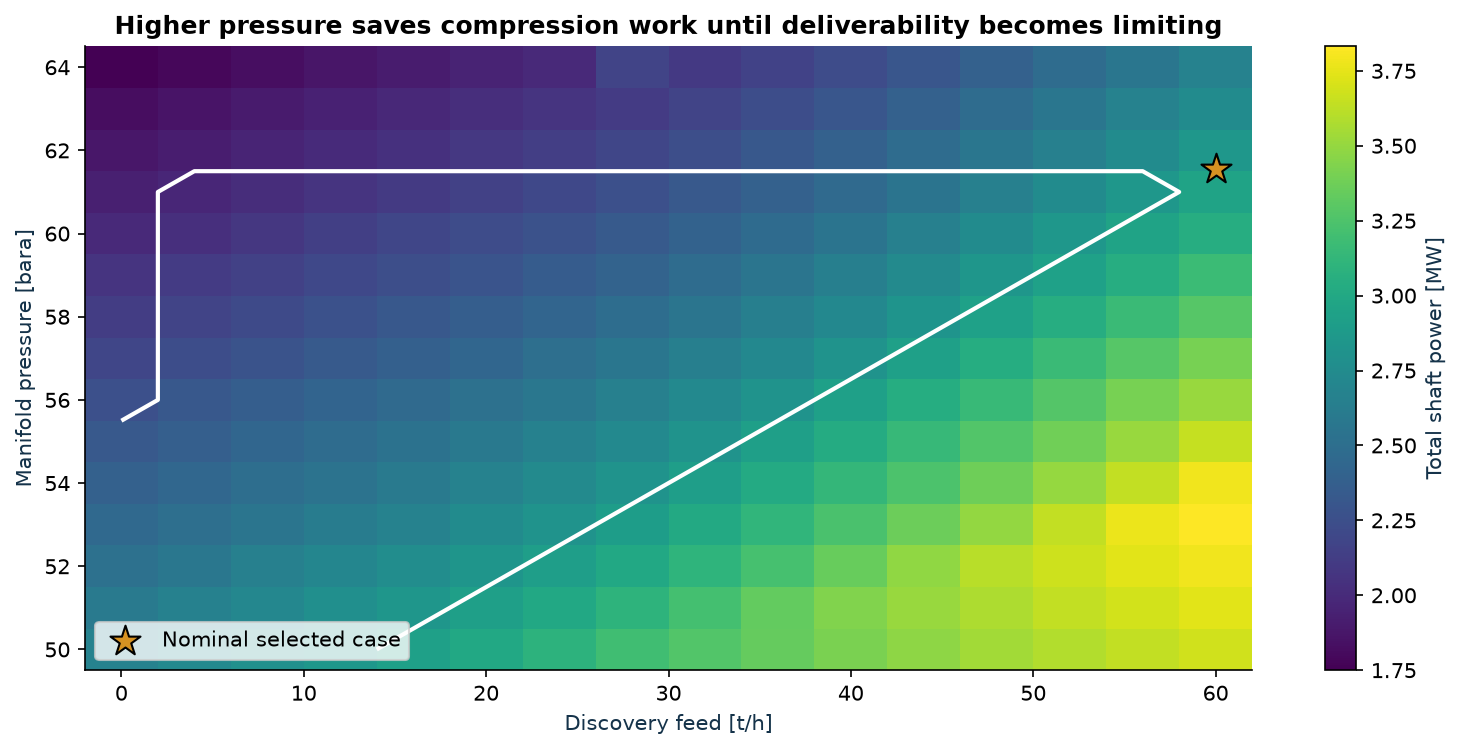

In [15]:
pressure_grid = np.linspace(50.0, 64.0, 15)
rate_grid = np.linspace(0.0, 60000.0, 16)
envelope = []
for pressure in pressure_grid:
    for rate in rate_grid:
        envelope.append(evaluate([float(rate), float(pressure), nominal["temperature_C"], 0.5]))
power_grid = np.array([r["power_kW"] for r in envelope]).reshape(15, 16)
feasible_grid = np.array([r["feasible"] for r in envelope]).reshape(15, 16)
figure, axis = plt.subplots(figsize=(10.5, 5.1))
mesh = axis.pcolormesh(
    rate_grid / 1000, pressure_grid, power_grid / 1000, cmap="viridis", shading="nearest"
)
axis.contour(
    rate_grid / 1000,
    pressure_grid,
    feasible_grid.astype(float),
    levels=[0.5],
    colors="white",
    linewidths=2,
)
axis.scatter(
    nominal["tie_kg_h"] / 1000,
    nominal["pressure_bara"],
    marker="*",
    s=230,
    color=COLORS["gold"],
    edgecolor="black",
    label="Nominal selected case",
)
axis.set(
    xlabel="Discovery feed [t/h]",
    ylabel="Manifold pressure [bara]",
    title="Higher pressure saves compression work until deliverability becomes limiting",
)
figure.colorbar(mesh, ax=axis, label="Total shaft power [MW]")
axis.legend(loc="lower left")
show_figure(figure, "05_operating_envelope")


### Sampled production–power trade-off

The nondominated points below come from the same fixed-temperature, equal-allocation grid.
A point is dominated when another sampled feasible point accepts at least as much discovery
feed while using no more shaft power. This is a sampled trade-off, not a globally optimized
Pareto frontier. The four-control optimizer and margin candidate are marked separately.

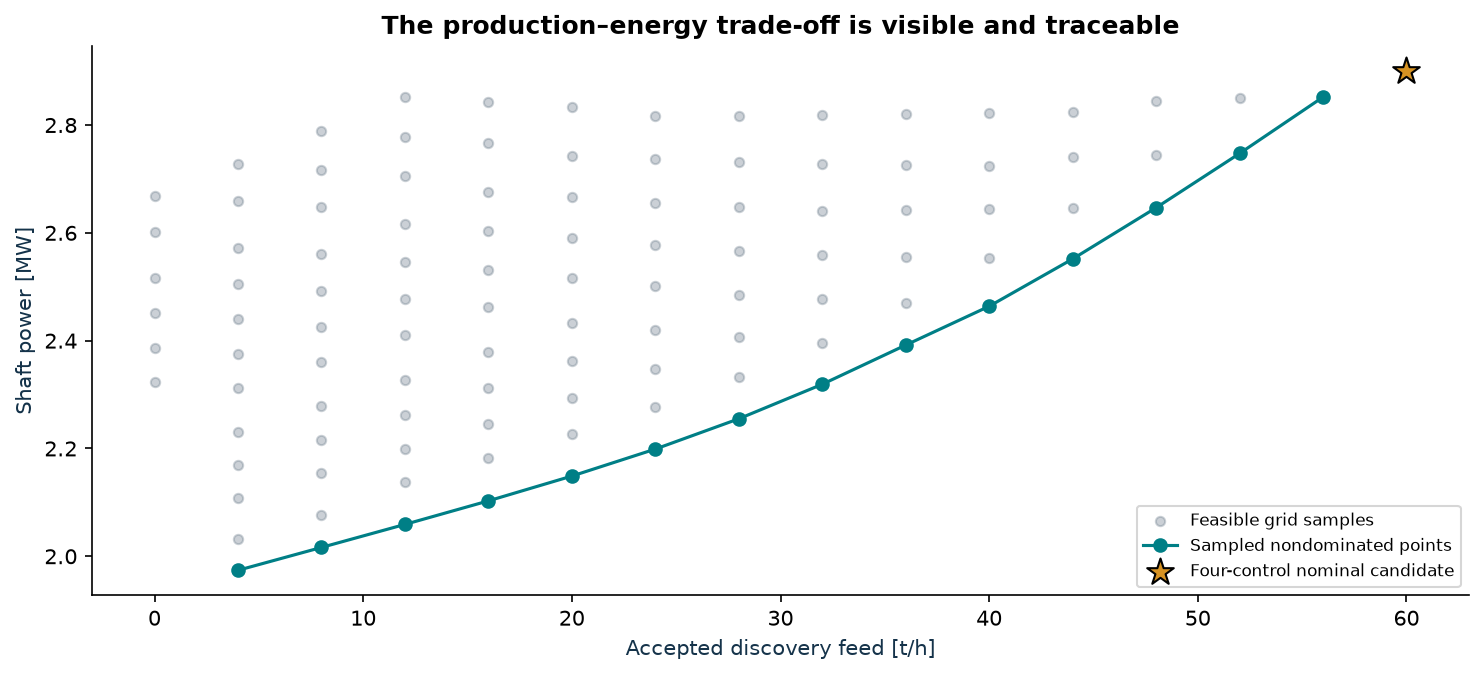

In [16]:
feasible_samples = [r for r in envelope if r["feasible"]]
frontier = []
for candidate in feasible_samples:
    dominated = any(
        other["tie_kg_h"] >= candidate["tie_kg_h"]
        and other["power_kW"] <= candidate["power_kW"]
        and (
            other["tie_kg_h"] > candidate["tie_kg_h"]
            or other["power_kW"] < candidate["power_kW"]
        )
        for other in feasible_samples
    )
    if not dominated:
        frontier.append(candidate)
frontier.sort(key=lambda result: result["tie_kg_h"])
figure, axis = plt.subplots(figsize=(10, 4.6))
axis.scatter(
    [r["tie_kg_h"] / 1000 for r in feasible_samples],
    [r["power_kW"] / 1000 for r in feasible_samples],
    color=COLORS["gray"],
    alpha=0.35,
    s=20,
    label="Feasible grid samples",
)
axis.plot(
    [r["tie_kg_h"] / 1000 for r in frontier],
    [r["power_kW"] / 1000 for r in frontier],
    "o-",
    color=COLORS["teal"],
    label="Sampled nondominated points",
)
axis.scatter(
    [nominal["tie_kg_h"] / 1000],
    [nominal["power_kW"] / 1000],
    marker="*",
    s=180,
    color=COLORS["gold"],
    edgecolor="black",
    label="Four-control nominal candidate",
)
axis.set(
    xlabel="Accepted discovery feed [t/h]",
    ylabel="Shaft power [MW]",
    title="The production–energy trade-off is visible and traceable",
)
axis.legend(fontsize=8)
show_figure(figure, "05b_sampled_tradeoff")


## 12 · Plotly asset explorer

Hover over a point to inspect its simulation ID and constraint. Use the dropdown to switch
between power and cooling. This figure explores already calculated cases; it does not interpolate
feasibility or issue new operating commands. The previous static envelope is the retained
fallback when notebook viewers do not execute JavaScript.

In [17]:
envelope_frame = pd.DataFrame([compact(row) for row in envelope])
interactive = go.Figure()
for metric, label in [("power_kW", "Shaft power [kW]"), ("cooling_kW", "Cooling duty [kW]")]:
    interactive.add_trace(
        go.Scatter(
            x=envelope_frame.tie_kg_h / 1000,
            y=envelope_frame.pressure_bara,
            mode="markers",
            marker=dict(
                size=9,
                color=envelope_frame[metric],
                colorscale="Viridis",
                colorbar=dict(title=label),
                symbol=np.where(envelope_frame.feasible, "circle", "x"),
            ),
            customdata=envelope_frame[["simulation_id", "limiting", "feasible"]].to_numpy(),
            hovertemplate="%{customdata[0]}<br>Discovery %{x:.1f} t/h<br>%{y:.2f} bara"
            "<br>Limiting: %{customdata[1]}<br>Feasible: %{customdata[2]}<extra></extra>",
            visible=metric == "power_kW",
            name=label,
        )
    )
interactive.update_layout(
    title="Asset explorer • circles feasible, crosses rejected",
    template="plotly_white",
    width=950,
    height=500,
    xaxis_title="Discovery feed [t/h]",
    yaxis_title="Manifold pressure [bara]",
    updatemenus=[
        dict(
            buttons=[
                dict(label="Power", method="update", args=[{"visible": [True, False]}]),
                dict(label="Cooling", method="update", args=[{"visible": [False, True]}]),
            ]
        )
    ],
)
interactive.write_html(OUTPUT / "asset_explorer.html", include_plotlyjs=True)
display(HTML(interactive.to_html(full_html=False, include_plotlyjs="cdn")))


## 13 · The surprise: Compressor 1 loses 15% of its driver power

> “Preserve existing-field production first. What should we do now?”

The old nominal recommendation must be re-evaluated under the new limit. Reusing a previously
feasible flag would be a serious decision error. We compare doing nothing, keeping the original
control settings while curtailing the discovery, and reallocating load while reoptimizing.

Strategy,tie_kg_h,pressure_bara,temperature_C,split,power_kW,feasible
Original settings / nominal,30265.694,55.000,30.000,0.500,2900.000,True
Optimized / nominal,60000.000,61.549,23.662,0.500,2899.574,True
Old recommendation / derated,60000.000,61.549,23.662,0.500,2899.574,False
Original settings / derated,6067.123,55.000,30.000,0.500,2465.000,True
Replanned / derated,52617.811,61.549,22.000,0.469,2682.500,True


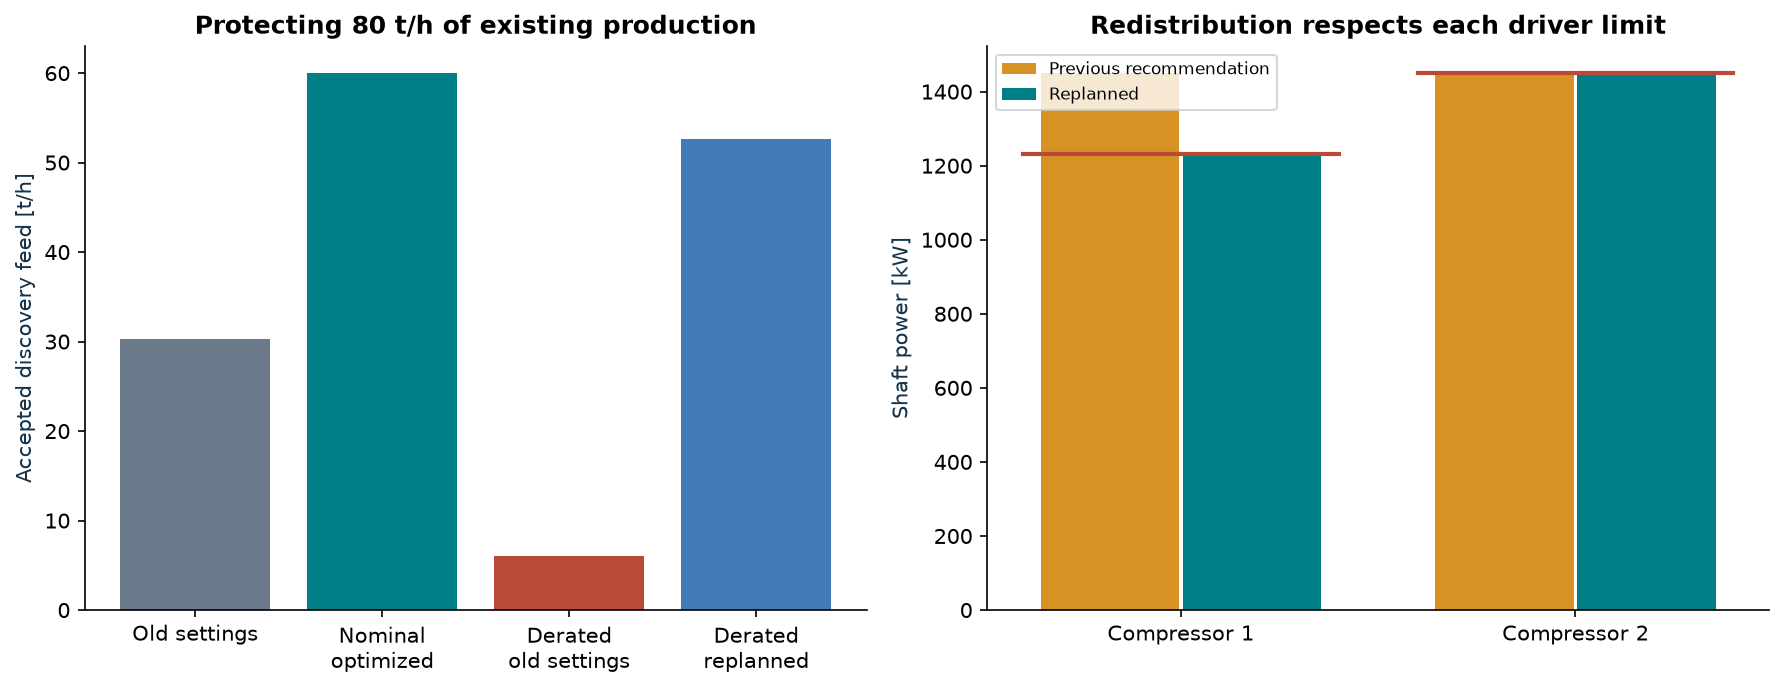

In [18]:
old_under_derating = evaluate(controls(nominal), derating=0.85, fresh=True)
fixed_derated, derated_sweep = fixed_setting_capacity(0.85)
derated_start = time.perf_counter()
derated_calls = COUNT
derated = optimize(0.85)
derated_metrics = {
    "seconds": time.perf_counter() - derated_start,
    "simulations": COUNT - derated_calls,
}
assert not old_under_derating["feasible"]
assert derated["feasible"]
comparison = pd.DataFrame(
    [
        {"Strategy": "Original settings / nominal", **compact(fixed_nominal)},
        {"Strategy": "Optimized / nominal", **compact(nominal)},
        {"Strategy": "Old recommendation / derated", **compact(old_under_derating)},
        {"Strategy": "Original settings / derated", **compact(fixed_derated)},
        {"Strategy": "Replanned / derated", **compact(derated)},
    ]
)
show_table(
    comparison[
        [
            "Strategy",
            "tie_kg_h",
            "pressure_bara",
            "temperature_C",
            "split",
            "power_kW",
            "feasible",
        ]
    ]
)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.7))
labels = ["Old settings", "Nominal\noptimized", "Derated\nold settings", "Derated\nreplanned"]
cases = [fixed_nominal, nominal, fixed_derated, derated]
axes[0].bar(
    labels,
    [r["tie_kg_h"] / 1000 for r in cases],
    color=[COLORS["gray"], COLORS["teal"], COLORS["red"], COLORS["blue"]],
)
axes[0].set(
    ylabel="Accepted discovery feed [t/h]", title="Protecting 80 t/h of existing production"
)
positions = np.arange(2)
axes[1].bar(
    positions - 0.18,
    [p["powerKW"] for p in old_under_derating["points"]],
    width=0.35,
    label="Previous recommendation",
    color=COLORS["gold"],
)
axes[1].bar(
    positions + 0.18,
    [p["powerKW"] for p in derated["points"]],
    width=0.35,
    label="Replanned",
    color=COLORS["teal"],
)
for index, limit in enumerate([1450 * 0.85, 1450]):
    axes[1].plot([index - 0.4, index + 0.4], [limit, limit], color=COLORS["red"], linewidth=2)
axes[1].set(
    xticks=positions,
    xticklabels=["Compressor 1", "Compressor 2"],
    ylabel="Shaft power [kW]",
    title="Redistribution respects each driver limit",
)
axes[1].legend(fontsize=8)
show_figure(figure, "06_derating_and_replanning")


## 14 · Uncertainty changes the operating decision

A nominal optimum often consumes all available margin. We propagate three independent,
explicitly synthetic uncertainties through **a full NeqSim process simulation for every
realization**:

| Uncertain input | Distribution | Interpretation |
|---|---|---|
| Discovery CO₂ offset | Uniform −0.8 to +0.8 mol percentage points | Methane adjusted by the opposite amount; fractions still sum to one |
| Separator temperature tracking error | Uniform 0 to +2 °C | Actual outlet warmer than requested; does not change compressor aftercooler setpoint |
| Compressor 1 available power | Uniform 97–103% of the derated value | Residual driver-capacity uncertainty |

The sample pass fraction is conditional on these distributions and model assumptions. It is
**not a plant reliability probability**. Correlated reservoir/measurement uncertainties,
vendor map uncertainty and model discrepancy would require a broader study.

First challenge the nominal derated optimum. Then reserve 8% of the driver, aftercooler and
CO₂ limit in the optimizer and test the revised candidate. A separate holdout seed checks that
the conclusion does not depend on reusing the design sample.

Case,tie_t_h,passed,cases,pass_fraction
Nominal derated optimum,52.618,2,96,0.021
8% margin candidate,42.912,96,96,1.000
8% margin / independent holdout,42.912,96,96,1.000


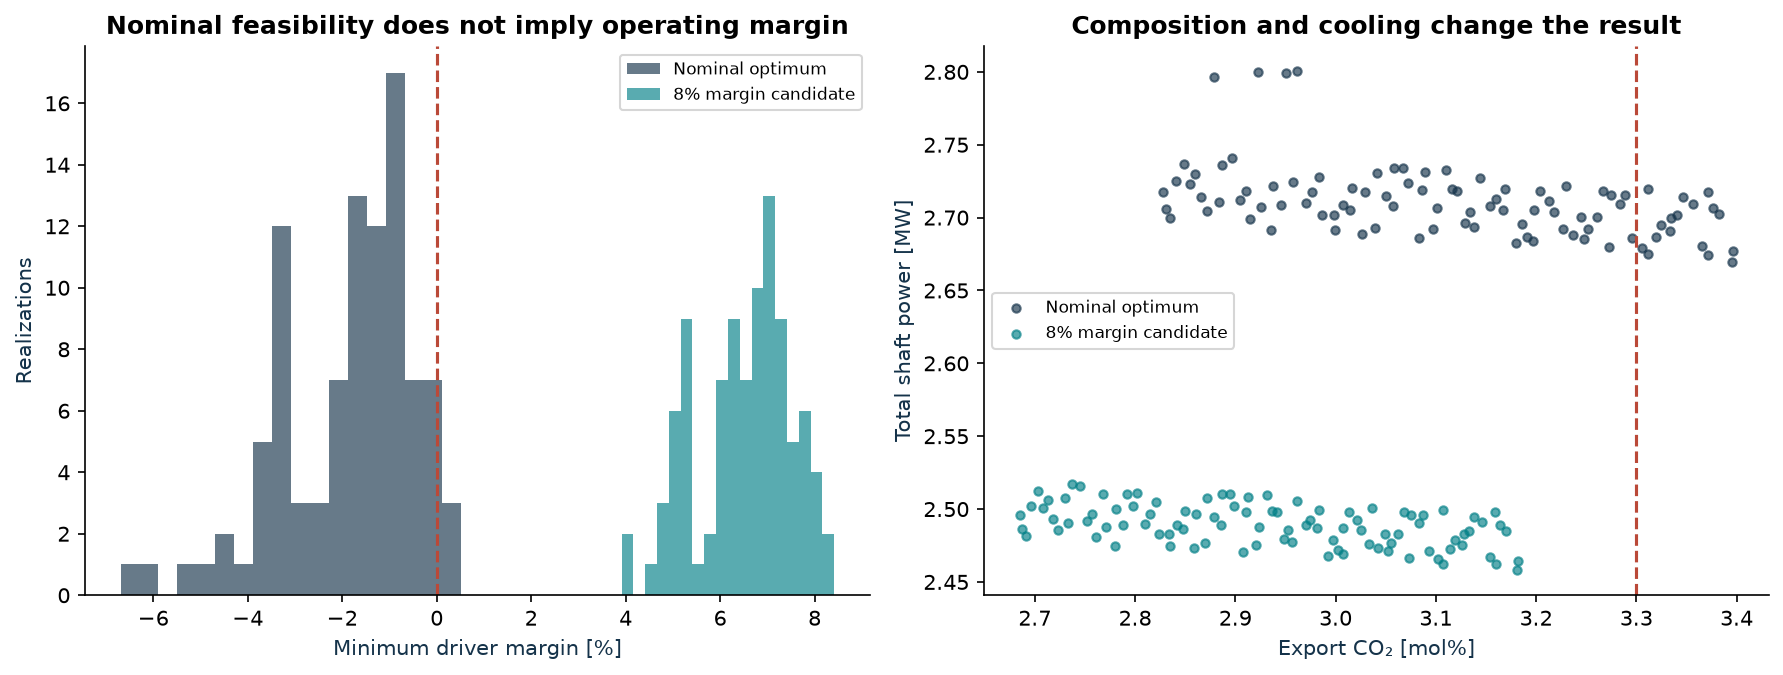

In [19]:
def stress_case(result, size=96, seed=718):
    sample = qmc.LatinHypercube(d=3, rng=np.random.default_rng(seed)).random(size)
    draws = qmc.scale(sample, [-0.008, 0.0, 0.97], [0.008, 2.0, 1.03])
    rows = []
    for index, (co2_offset, tracking_error, driver_factor) in enumerate(draws):
        trial = evaluate(
            controls(result),
            derating=result["derating"] * driver_factor,
            upgrade=result["upgrade"],
            co2_delta=co2_offset,
            ambient=tracking_error,
            fresh=True,
        )
        rows.append(
            {
                "realization": index,
                **compact(trial),
                "co2_offset": co2_offset,
                "tracking_error_C": tracking_error,
                "driver_factor": driver_factor,
                "minimum_driver_margin": min(
                    trial["margins"]["driver_1"], trial["margins"]["driver_2"]
                ),
                "CO2_margin": trial["margins"]["CO2"],
            }
        )
    return pd.DataFrame(rows)


stress_nominal = stress_case(derated)
robust = optimize(0.85, margin=0.08)
stress_robust = stress_case(robust)
holdout_robust = stress_case(robust, size=96, seed=20260912)
uncertainty_summary = pd.DataFrame(
    [
        {
            "Case": "Nominal derated optimum",
            "tie_t_h": derated["tie_kg_h"] / 1000,
            "passed": int(stress_nominal.feasible.sum()),
            "cases": len(stress_nominal),
        },
        {
            "Case": "8% margin candidate",
            "tie_t_h": robust["tie_kg_h"] / 1000,
            "passed": int(stress_robust.feasible.sum()),
            "cases": len(stress_robust),
        },
        {
            "Case": "8% margin / independent holdout",
            "tie_t_h": robust["tie_kg_h"] / 1000,
            "passed": int(holdout_robust.feasible.sum()),
            "cases": len(holdout_robust),
        },
    ]
)
uncertainty_summary["pass_fraction"] = uncertainty_summary.passed / uncertainty_summary.cases
show_table(uncertainty_summary)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for frame, label in [
    (stress_nominal, "Nominal optimum"),
    (stress_robust, "8% margin candidate"),
]:
    axes[0].hist(frame.minimum_driver_margin * 100, bins=18, alpha=0.65, label=label)
    axes[1].scatter(frame.co2_mol_pct, frame.power_kW / 1000, s=16, alpha=0.65, label=label)
axes[0].axvline(0, color=COLORS["red"], linestyle="--")
axes[0].set(
    xlabel="Minimum driver margin [%]",
    ylabel="Realizations",
    title="Nominal feasibility does not imply operating margin",
)
axes[1].axvline(3.3, color=COLORS["red"], linestyle="--")
axes[1].set(
    xlabel="Export CO₂ [mol%]",
    ylabel="Total shaft power [MW]",
    title="Composition and cooling change the result",
)
for axis in axes:
    axis.legend(fontsize=8)
show_figure(figure, "07_uncertainty_challenge")


## 15 · Quantify the remaining shortfall and the upgrade options

The driver package increases both nominal driver ratings by 20%; the 15% Train 1 derating
still applies. The cooler package adds 25% aftercooler thermal capacity. The combined package
does both. Compressor aerodynamic maps, speed limits and source deliverability are unchanged.
These packages are design hypotheses, not evidence that an installed driver can be uprated.

The comparison asks which of these discrete packages restores the requested nomination. It
does not claim a continuous or globally minimum hardware modification. A driver-only solution
can move the limiting constraint to cooling or gas quality; a cooler-only package may have
almost no production value while shaft power is the active limit.

Package,Accepted discovery [t/h],Shortfall [t/h],Power [MW],Limiting screen,Feasible
none,52.618,7.382,2.683,driver_1,True
driver,60.000,0.000,3.104,aftercooler_2,True
cooler,52.618,7.382,2.683,driver_1,True
combined,60.000,0.000,3.110,driver_2,True


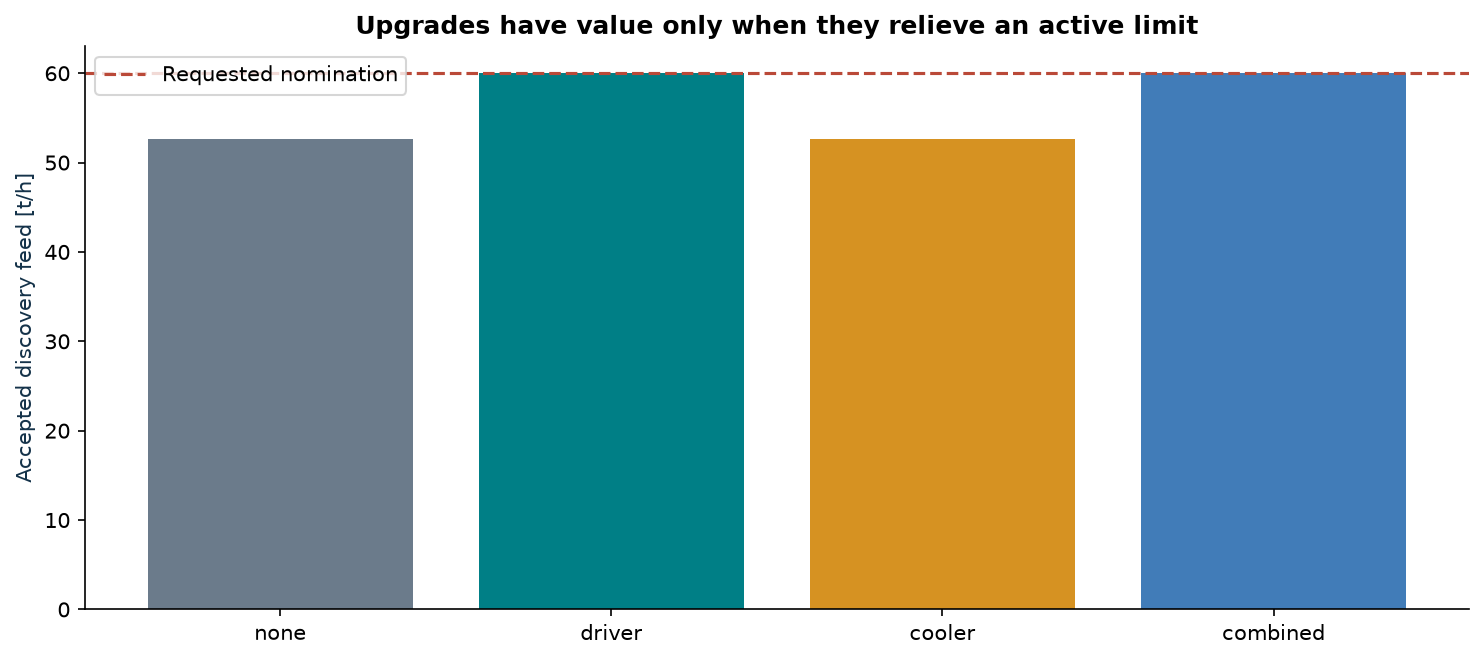

In [20]:
upgrades = {name: optimize(0.85, name) for name in ["driver", "cooler", "combined"]}
upgrade_frame = pd.DataFrame(
    [
        {
            "Package": name,
            "Accepted discovery [t/h]": result["tie_kg_h"] / 1000,
            "Shortfall [t/h]": (60000 - result["tie_kg_h"]) / 1000,
            "Power [MW]": result["power_kW"] / 1000,
            "Limiting screen": result["limiting"],
            "Feasible": result["feasible"],
        }
        for name, result in {"none": derated, **upgrades}.items()
    ]
)
show_table(upgrade_frame)
figure, axis = plt.subplots(figsize=(10, 4.5))
axis.bar(
    upgrade_frame.Package,
    upgrade_frame["Accepted discovery [t/h]"],
    color=[COLORS["gray"], COLORS["teal"], COLORS["gold"], COLORS["blue"]],
)
axis.axhline(60, color=COLORS["red"], linestyle="--", label="Requested nomination")
axis.set(
    ylabel="Accepted discovery feed [t/h]",
    title="Upgrades have value only when they relieve an active limit",
)
axis.legend()
show_figure(figure, "08_upgrade_screen")


## 16 · Mass, component and energy evidence for the selected case

The next tables expose the numbers behind the audit instead of displaying only a green tick.
The selected case is the 8% driver/cooling/CO₂ reserve candidate under derating.
The reduced Field B deliverability screen remains active and is not included in that reserve.
Keep the exact JSON setpoints for reproduction; rounded display values are not a separately
validated operating instruction. There is no chemical reaction in
this model, so the mole flow of every component must be conserved across all product outlets.
Compressor work and negative cooler duties must close the whole-process enthalpy balance.

Stream,Mass [kg/h],Moles [mol/s],Pressure [bara],Temperature [°C],h [kJ/kg]
Host A,50000.000,682.789,80.000,45.0,-0.348
Host B,30000.000,383.997,75.000,45.0,-3.274
Discovery,42911.549,512.870,90.000,45.0,-29.210
Export manifold mixed stream,118668.211,1554.237,110.000,30.0,-86.651
liquidOutStream,4243.338,25.418,61.549,22.0,-314.661
liquidOutStream,0.000,0.000,110.000,30.0,19.648
liquidOutStream,0.000,0.000,110.000,30.0,19.648


Component,In [mol/s],Out [mol/s],Residual [mol/s]
nitrogen,15.796554,15.796554,0.0
CO2,46.129621,46.129621,0.0
methane,1234.648844,1234.648844,0.0
ethane,137.055857,137.055857,0.0
propane,82.617511,82.617511,0.0
n-butane,40.561775,40.561775,0.0
n-pentane,16.312539,16.312539,0.0
n-hexane,6.532700,6.532700,0.0


Equipment,Signed duty [kW]
Compressor 1,1133.900
Compressor 2,1334.000
Inlet cooler,-1388.496
Aftercooler 1,-1810.618
Aftercooler 2,-2115.709


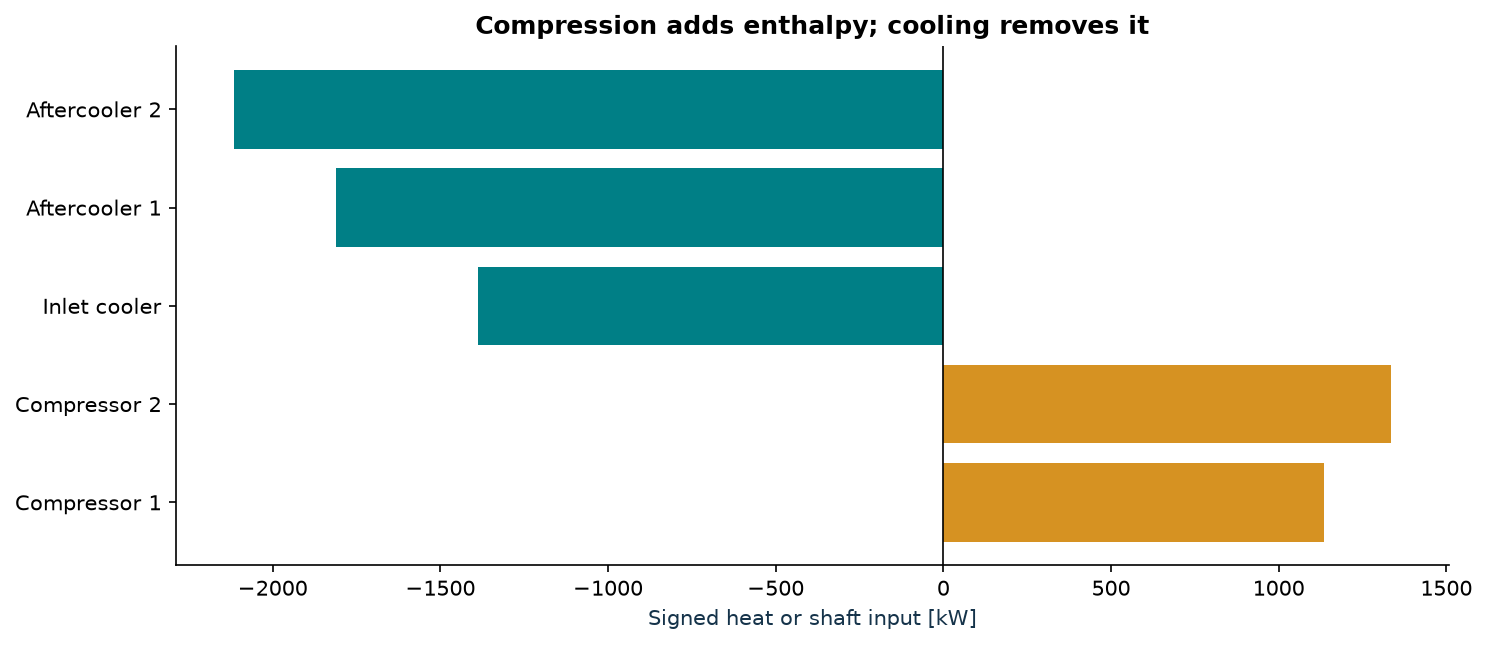

In [21]:
selected_model = build(
    tie=robust["tie_kg_h"],
    pressure=robust["pressure_bara"],
    temperature=robust["temperature_C"],
    split=robust["split"],
    maps=MAPS,
)
products = [selected_model["export"]] + [
    unit.getLiquidOutStream() for unit in selected_model["separators"]
]
stream_rows = []
for stream in selected_model["feeds"] + products:
    stream_rows.append(
        {
            "Stream": str(stream.getName()),
            "Mass [kg/h]": float(stream.getFlowRate("kg/hr")),
            "Moles [mol/s]": float(stream.getFlowRate("mole/sec")),
            "Pressure [bara]": float(stream.getPressure("bara")),
            "Temperature [°C]": float(stream.getTemperature("C")),
            "h [kJ/kg]": float(stream.getFluid().getEnthalpy("kJ/kg")),
        }
    )
show_table(pd.DataFrame(stream_rows))
component_rows = []
for component in COMPONENTS:
    inlet = sum(
        float(s.getFlowRate("mole/sec")) * float(s.getFluid().getComponent(component).getz())
        for s in selected_model["feeds"]
    )
    outlet = sum(
        float(s.getFlowRate("mole/sec")) * float(s.getFluid().getComponent(component).getz())
        for s in products
    )
    component_rows.append(
        {
            "Component": component,
            "In [mol/s]": inlet,
            "Out [mol/s]": outlet,
            "Residual [mol/s]": outlet - inlet,
        }
    )
show_table(pd.DataFrame(component_rows), 9)
energy_rows = [
    {"Equipment": str(c.getName()), "Signed duty [kW]": float(c.getPower("kW"))}
    for c in selected_model["compressors"]
]
energy_rows += [
    {"Equipment": str(c.getName()), "Signed duty [kW]": float(c.getDuty()) / 1000}
    for c in selected_model["coolers"]
]
show_table(pd.DataFrame(energy_rows))
figure, axis = plt.subplots(figsize=(10, 4.4))
energy_frame = pd.DataFrame(energy_rows)
axis.barh(
    energy_frame.Equipment,
    energy_frame["Signed duty [kW]"],
    color=[COLORS["gold"]] * 2 + [COLORS["teal"]] * 3,
)
axis.axvline(0, color="black", linewidth=0.8)
axis.set(
    xlabel="Signed heat or shaft input [kW]",
    title="Compression adds enthalpy; cooling removes it",
)
show_figure(figure, "09_enthalpy_accounting")


## 17 · Independent compression check and EOS sensitivity

A constant-property ideal-gas calculation supplies an independent order-of-magnitude check:

$$w_s=\frac{k}{k-1}\frac{RT_1}{M}\left[\left(\frac{p_2}{p_1}\right)^{(k-1)/k}-1\right]$$

$R$ is 8.314462618 J/(mol K), $M$ molar mass in kg/mol, $k$ the assumed heat-capacity ratio,
and $T_1$ suction temperature in K. Dividing by an assumed isentropic efficiency gives a rough
shaft-work estimate. This is **not equivalent to the real-gas polytropic map calculation**;
the residual is shown, not calibrated away. Conservation remains the tighter numerical gate.

PR is run through the same fixed equipment maps and limits. Changing EOS tests model-form
sensitivity, not agreement with an independent experimental benchmark.

In [22]:
ideal_rows = []
for compressor in selected_model["compressors"]:
    inlet = compressor.getInletStream()
    molar_mass = float(inlet.getFluid().getMolarMass("kg/mol"))
    ratio = 110.0 / float(inlet.getPressure("bara"))
    exponent = 1.27
    ideal_work = (
        exponent / (exponent - 1) * 8.314462618 * float(inlet.getTemperature("K")) / molar_mass
    )
    ideal_work *= (ratio ** ((exponent - 1) / exponent) - 1) / 0.78
    ideal_power = ideal_work * float(inlet.getFlowRate("kg/sec")) / 1000
    actual_power = float(compressor.getPower("kW"))
    ideal_rows.append(
        {
            "Compressor": str(compressor.getName()),
            "Ideal screen [kW]": ideal_power,
            "NeqSim map [kW]": actual_power,
            "Difference [%]": 100 * (actual_power / ideal_power - 1),
        }
    )
    assert 0.5 < actual_power / ideal_power < 1.5
show_table(pd.DataFrame(ideal_rows))
pr_case = evaluate(controls(robust), derating=0.85, eos="PR", fresh=True)
show_table(
    pd.DataFrame([{"EOS": "SRK", **compact(robust)}, {"EOS": "PR", **compact(pr_case)}])[
        ["EOS", "power_kW", "liquid_kg_h", "co2_mol_pct", "wobbe_MJ_Sm3", "feasible"]
    ]
)


Compressor,Ideal screen [kW],NeqSim map [kW],Difference [%]
Compressor 1,1402.225,1133.9,-19.136
Compressor 2,1619.776,1334.0,-17.643


EOS,power_kW,liquid_kg_h,co2_mol_pct,wobbe_MJ_Sm3,feasible
SRK,2467.900,4243.338,2.936,52.332,True
PR,2387.722,3281.216,2.933,52.441,True


## 18 · Export boundary: investigate downstream condensation

Host feasibility does not establish pipeline suitability. The export gas is flashed over a
pressure–temperature grid to reveal possible downstream hydrocarbon condensation. Each point
uses a clone of the calculated export composition. This is equilibrium phase screening, not
two-fluid hydraulics, liquid accumulation, hydrate prediction or a contractual dew-point test.
The final engineering brief explicitly leaves downstream qualification open.

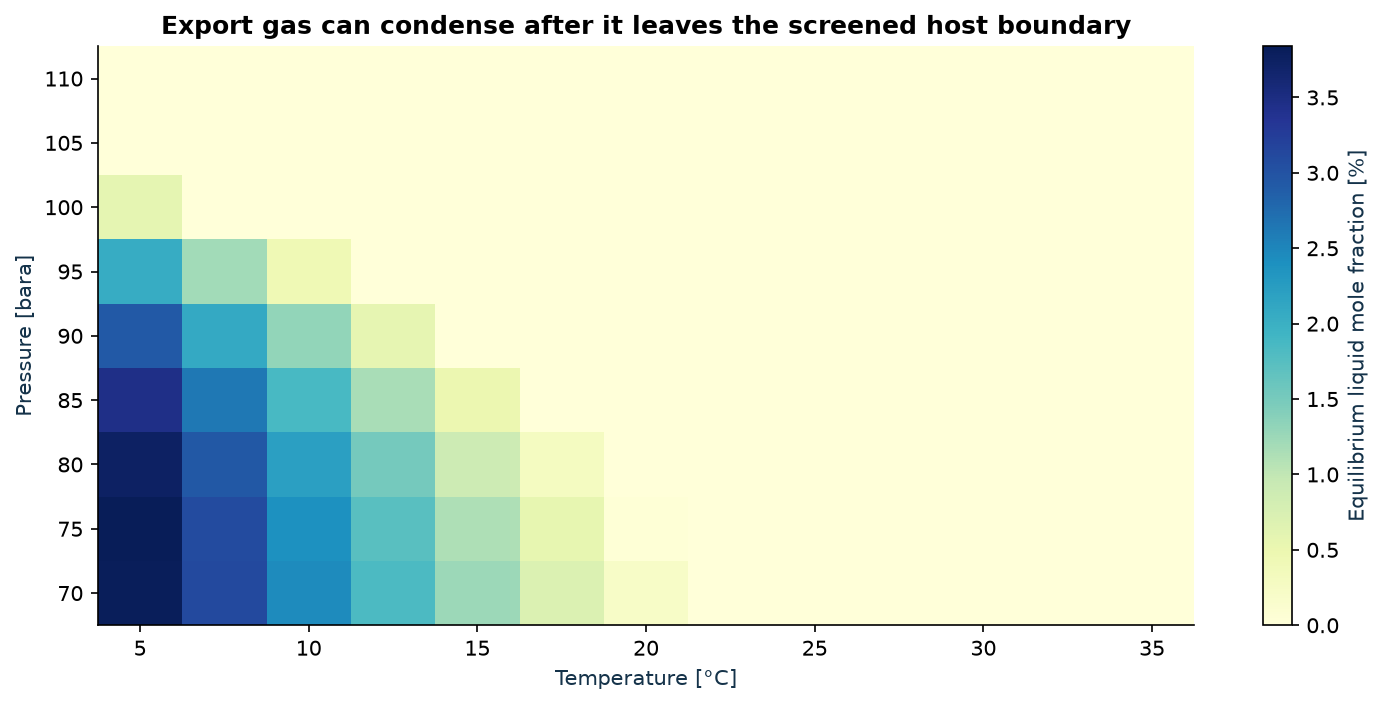

In [23]:
flash_rows = []
for pressure in np.linspace(70, 110, 9):
    for temperature in np.linspace(5, 35, 13):
        fluid = selected_model["export"].getFluid().clone()
        fluid.setPressure(float(pressure))
        fluid.setTemperature(float(temperature) + 273.15)
        fluid.setMultiPhaseCheck(True)
        ns.thermodynamicoperations.ThermodynamicOperations(fluid).TPflash()
        total_moles = float(fluid.getTotalNumberOfMoles())
        gas_moles = (
            float(fluid.getPhase("gas").getNumberOfMolesInPhase())
            if fluid.hasPhaseType("gas")
            else 0.0
        )
        liquid_fraction = max(0.0, 1.0 - gas_moles / total_moles)
        assert 0.0 <= liquid_fraction <= 1.0
        flash_rows.append(
            {
                "pressure_bara": pressure,
                "temperature_C": temperature,
                "liquid_mole_fraction": liquid_fraction,
            }
        )
flash_frame = pd.DataFrame(flash_rows)
figure, axis = plt.subplots(figsize=(10, 4.8))
mesh = axis.pcolormesh(
    np.linspace(5, 35, 13),
    np.linspace(70, 110, 9),
    flash_frame.liquid_mole_fraction.to_numpy().reshape(9, 13) * 100,
    shading="nearest",
    cmap="YlGnBu",
)
axis.set(
    xlabel="Temperature [°C]",
    ylabel="Pressure [bara]",
    title="Export gas can condense after it leaves the screened host boundary",
)
figure.colorbar(mesh, ax=axis, label="Equilibrium liquid mole fraction [%]")
show_figure(figure, "10_export_phase_screen")


## 19 · Economics and emissions: state the boundary before calculating value

This is an **illustrative pretax, unlevered project comparison in constant euros**, not a tax
model or an investment recommendation. Every price and cost is an explicit synthetic scenario.
There is no claim that these are current market quotations or vendor estimates.

| Economic assumption | Base value |
|---|---:|
| Gas price on gross calorific energy | 30 EUR/MWh |
| Condensate value | 400 EUR/t |
| Imported electricity | 90 EUR/MWh |
| Electricity emissions intensity | 0.35 kg CO₂e/kWh |
| Internal carbon value | 100 EUR/t CO₂e |
| Operating hours per year | 8,000 h |
| Motor efficiency | 97% |
| Cooling pump power | 1.5% of heat removed |
| Discovery rate decline | 10% per year after Year 1 |
| Base recoverable feed resource | 2.0 billion kg |
| Evaluation horizon / discount rate | 5 years / 10% |
| Common tie-back CAPEX / fixed OPEX | 80 million EUR / 2 million EUR per year |
| Driver / cooler / combined incremental CAPEX | 8 / 4 / 12 million EUR |

Condensate is valued as raw recovered liquid for screening; stabilization and product acceptance
are not modelled. Gas and condensate are counted as separate products, never both valued as gas.
The reference is the feasible 80 t/h host baseline under derating at its original settings.
Therefore project increments include the effect of changing host operating conditions; they are
not a claim of molecular ownership of commingled products.

$$P_{elec}=P_{shaft}/\eta_{motor}+0.015\,Q_{removed}$$

$$E_{gas}=q_{gas,Sm^3/h}\,GCV/3600$$

With GCV in MJ/Sm³, gas energy rate is MW. Electricity is kW. The emissions boundary is imported
electricity only; no direct combustion, methane leakage, embodied emissions or product end use
is included. Increased production can raise absolute emissions while reducing intensity.

$$NPV=-CAPEX+\sum_{y=1}^{5}\frac{\Delta Revenue_y-\Delta OPEX_y}{(1+r)^y}$$

Every annual operating point is re-simulated. Resource mass remaining caps the requested tie-back
rate. A rejected annual candidate falls back to the checked host-only baseline and books no
tie-back production. Deferred resource is not silently converted into revenue.

Strategy,NPV [million EUR],CAPEX [million EUR],Produced feed [million tonnes]
Derated nominal,436.417,80.0,1.724
8% margin,340.169,80.0,1.406
Driver,501.262,88.0,1.966
Cooler,432.417,84.0,1.724
Combined,497.277,92.0,1.966


year,accepted_tie_t_h,resource_left_Mt,cash_flow_MEUR,discounted_MEUR,incremental_CO2e_t,simulation_id,candidate_feasible
1,42.912,1.657,132.965,120.877,284.293,SIM-00721,True
2,38.620,1.348,119.532,98.787,29.937,SIM-01168,True
3,34.758,1.070,107.429,80.713,-158.747,SIM-01169,True
4,31.283,0.819,96.539,65.937,-333.478,SIM-01170,True
5,28.154,0.594,86.733,53.854,-478.388,SIM-01171,True


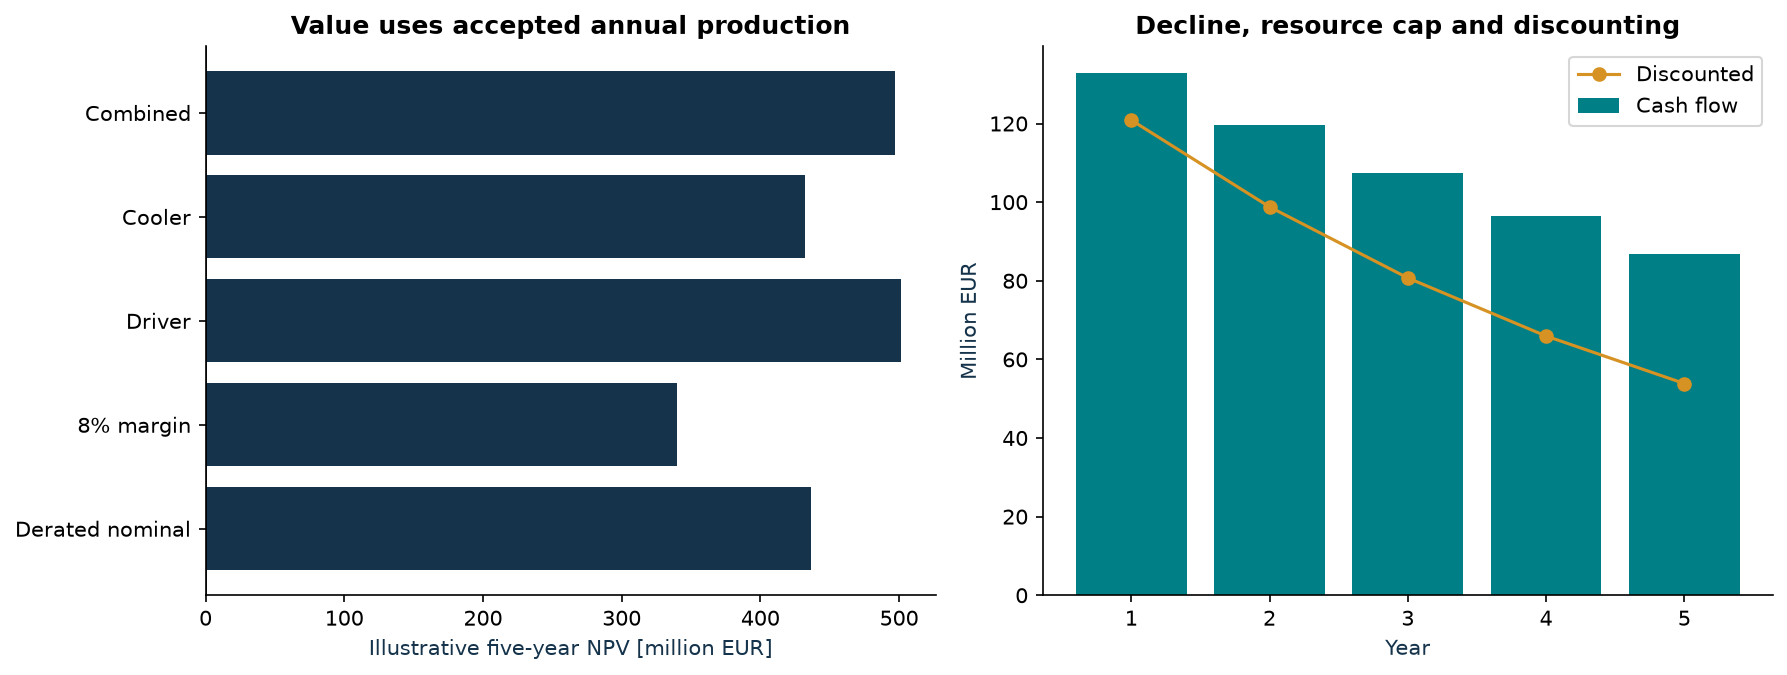

In [24]:
ECONOMICS = {
    "gas_eur_MWh": 30.0,
    "liquid_eur_t": 400.0,
    "electricity_eur_MWh": 90.0,
    "carbon_eur_t": 100.0,
    "electricity_kg_CO2e_kWh": 0.35,
    "hours": 8000.0,
    "discount": 0.10,
    "fixed_opex_eur": 2e6,
    "tieback_capex_eur": 80e6,
}
PACKAGE_CAPEX = {"none": 0.0, "driver": 8e6, "cooler": 4e6, "combined": 12e6}


def rates(result, assumptions=ECONOMICS):
    gas_MW = result["gas_Sm3_h"] * result["gcv_MJ_Sm3"] / 3600
    electricity_kW = result["power_kW"] / 0.97 + 0.015 * result["cooling_kW"]
    emissions_t_h = electricity_kW * assumptions["electricity_kg_CO2e_kWh"] / 1000
    revenue = gas_MW * assumptions["gas_eur_MWh"]
    revenue += result["liquid_kg_h"] / 1000 * assumptions["liquid_eur_t"]
    variable_cost = electricity_kW / 1000 * assumptions["electricity_eur_MWh"]
    variable_cost += emissions_t_h * assumptions["carbon_eur_t"]
    return {
        "gas_MW": gas_MW,
        "electricity_kW": electricity_kW,
        "emissions_t_h": emissions_t_h,
        "margin_eur_h": revenue - variable_cost,
        "electricity_CO2e_kg_MWh_gas": emissions_t_h * 1000 / gas_MW,
    }


economic_baseline = evaluate([0.0, 55.0, 30.0, 0.5], derating=0.85, fresh=True)
assert economic_baseline["feasible"]


def economics(result, resource_kg=2e9, gas_price=30.0, capex_factor=1.0, decline=0.10):
    assumptions = dict(ECONOMICS, gas_eur_MWh=gas_price)
    base_rates = rates(economic_baseline, assumptions)
    resource_left = resource_kg
    annual = []
    capital = (
        assumptions["tieback_capex_eur"] + PACKAGE_CAPEX[result["upgrade"]]
    ) * capex_factor
    npv = -capital
    for year in range(1, 6):
        proposed = min(
            result["tie_kg_h"] * (1 - decline) ** (year - 1),
            resource_left / assumptions["hours"],
        )
        annual_controls = controls(result)
        annual_controls[0] = max(proposed, 0.0)
        trial = evaluate(
            annual_controls, derating=result["derating"], upgrade=result["upgrade"]
        )
        accepted = proposed if trial["feasible"] else 0.0
        operated = trial if trial["feasible"] else economic_baseline
        annual_rates = rates(operated, assumptions)
        produced = accepted * assumptions["hours"]
        resource_left -= produced
        cash_flow = (annual_rates["margin_eur_h"] - base_rates["margin_eur_h"]) * assumptions[
            "hours"
        ]
        cash_flow -= assumptions["fixed_opex_eur"]
        discounted = cash_flow / (1 + assumptions["discount"]) ** year
        npv += discounted
        annual.append(
            {
                "year": year,
                "accepted_tie_t_h": accepted / 1000,
                "resource_left_Mt": resource_left / 1e9,
                "cash_flow_MEUR": cash_flow / 1e6,
                "discounted_MEUR": discounted / 1e6,
                "incremental_CO2e_t": (
                    annual_rates["emissions_t_h"] - base_rates["emissions_t_h"]
                )
                * assumptions["hours"],
                "simulation_id": operated["simulation_id"],
                "candidate_feasible": trial["feasible"],
            }
        )
    assert resource_left >= -1e-4
    return {
        "npv_MEUR": npv / 1e6,
        "capex_MEUR": capital / 1e6,
        "annual": annual,
        "produced_Mt": (resource_kg - resource_left) / 1e9,
    }


economic_cases = {
    "Derated nominal": derated,
    "8% margin": robust,
    "Driver": upgrades["driver"],
    "Cooler": upgrades["cooler"],
    "Combined": upgrades["combined"],
}
economic_results = {name: economics(result) for name, result in economic_cases.items()}
show_table(
    pd.DataFrame(
        [
            {
                "Strategy": name,
                "NPV [million EUR]": value["npv_MEUR"],
                "CAPEX [million EUR]": value["capex_MEUR"],
                "Produced feed [million tonnes]": value["produced_Mt"],
            }
            for name, value in economic_results.items()
        ]
    )
)
show_table(pd.DataFrame(economic_results["8% margin"]["annual"]))
figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].barh(list(economic_results), [v["npv_MEUR"] for v in economic_results.values()])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(
    xlabel="Illustrative five-year NPV [million EUR]",
    title="Value uses accepted annual production",
)
annual = pd.DataFrame(economic_results["8% margin"]["annual"])
axes[1].bar(annual.year, annual.cash_flow_MEUR, color=COLORS["teal"], label="Cash flow")
axes[1].plot(
    annual.year, annual.discounted_MEUR, "o-", color=COLORS["gold"], label="Discounted"
)
axes[1].set(xlabel="Year", ylabel="Million EUR", title="Decline, resource cap and discounting")
axes[1].legend()
show_figure(figure, "11_economic_screen")


## 20 · Resource and commercial uncertainty

The resource is uncertain: uniform 1.5–2.5 billion kg. Gas price spans 20–40 EUR/MWh, CAPEX
multiplier 0.8–1.3 and annual discovery decline 6–14%. These distributions are independent
teaching assumptions. Each realization carries its own resource balance and five annual
NeqSim operating evaluations. Caching only reuses exactly identical physical inputs; it never
reuses a result for a different composition, pressure, temperature or disturbance.

The distribution answers a conditional scenario question. It is not a reserves assessment.
The plot separately shows electricity-related absolute emissions and gas energy intensity.

Non-exceedance quantile,npv_MEUR,produced_Mt
0.1,237.504,1.322
0.5,333.528,1.406
0.9,442.874,1.496


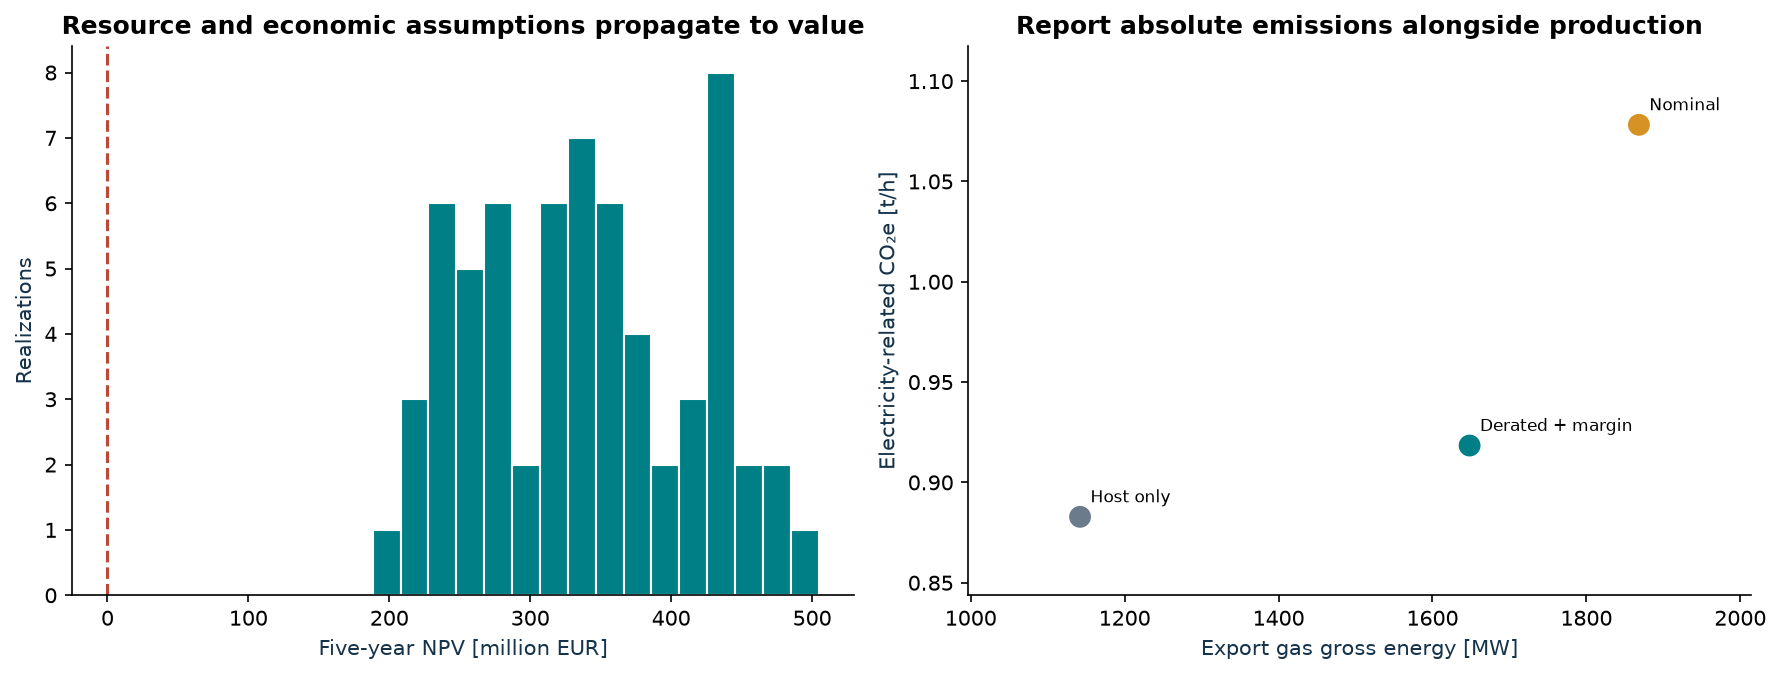

Case,gas_MW,emissions_t_h,electricity_CO2e_kg_MWh_gas
Host only,1142.026,0.883,0.773
Nominal,1868.269,1.078,0.577
Derated + margin,1648.225,0.918,0.557


In [25]:
economic_draws = qmc.scale(
    qmc.LatinHypercube(d=4, rng=np.random.default_rng(411)).random(64),
    [1.5e9, 20.0, 0.8, 0.06],
    [2.5e9, 40.0, 1.3, 0.14],
)
economic_uncertainty = []
for resource, price, capital_factor, decline in economic_draws:
    value = economics(robust, resource, price, capital_factor, decline)
    economic_uncertainty.append(
        {
            "resource_Mt": resource / 1e9,
            "gas_price": price,
            "capex_factor": capital_factor,
            "decline": decline,
            "npv_MEUR": value["npv_MEUR"],
            "produced_Mt": value["produced_Mt"],
        }
    )
economic_uncertainty = pd.DataFrame(economic_uncertainty)
show_table(
    economic_uncertainty[["npv_MEUR", "produced_Mt"]]
    .quantile([0.1, 0.5, 0.9])
    .reset_index(names="Non-exceedance quantile")
)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(economic_uncertainty.npv_MEUR, bins=16, color=COLORS["teal"], edgecolor="white")
axes[0].axvline(0, color=COLORS["red"], linestyle="--")
axes[0].set(
    xlabel="Five-year NPV [million EUR]",
    ylabel="Realizations",
    title="Resource and economic assumptions propagate to value",
)
emission_rows = [
    {"Case": name, **rates(result)}
    for name, result in {
        "Host only": economic_baseline,
        "Nominal": nominal,
        "Derated + margin": robust,
    }.items()
]
emission_frame = pd.DataFrame(emission_rows)
axes[1].scatter(
    emission_frame.gas_MW,
    emission_frame.emissions_t_h,
    s=90,
    color=[COLORS["gray"], COLORS["gold"], COLORS["teal"]],
)
for row in emission_rows:
    axes[1].annotate(
        row["Case"],
        (row["gas_MW"], row["emissions_t_h"]),
        xytext=(5, 7),
        textcoords="offset points",
        fontsize=8,
    )
axes[1].margins(0.2)
axes[1].set(
    xlabel="Export gas gross energy [MW]",
    ylabel="Electricity-related CO₂e [t/h]",
    title="Report absolute emissions alongside production",
)
show_figure(figure, "12_economic_uncertainty_and_emissions")
show_table(emission_frame[["Case", "gas_MW", "emissions_t_h", "electricity_CO2e_kg_MWh_gas"]])


### Declining source pressure: revisit the operating envelope over field life

Rate decline and pressure decline are different physical assumptions. The five-year economic
screen above used an explicit discovery-rate decline with fixed source pressures. This separate
calculation reduces **all three source pressures by 0, 3 and 6 bar**, representing illustrative
future pressure snapshots rather than a reservoir forecast. Both protected host rates remain
unchanged. Each source fluid enters its actual lower-pressure choke; the deliverability relation
is recomputed with the lower source pressure while its original calibration coefficient
(including the reference-pressure denominator) remains fixed. The complete host is reoptimized under the
Compressor 1 derating.

This prevents the agent from reusing a high-pressure recommendation after its source conditions
change. A reduced well model cannot predict the date of these snapshots; the reservoir/well
workflow must supply that information before integrating pressure decline into project NPV.

Source-pressure decline [bar],Previous settings feasible,Replanned discovery [t/h],Manifold pressure [bara],Replanned feasible,Limiting constraint,Simulation ID
0.0,True,52.618,61.549,True,driver_1,SIM-01442
3.0,False,37.830,57.856,True,driver_2,SIM-01504
6.0,False,20.630,54.076,True,driver_2,SIM-01643


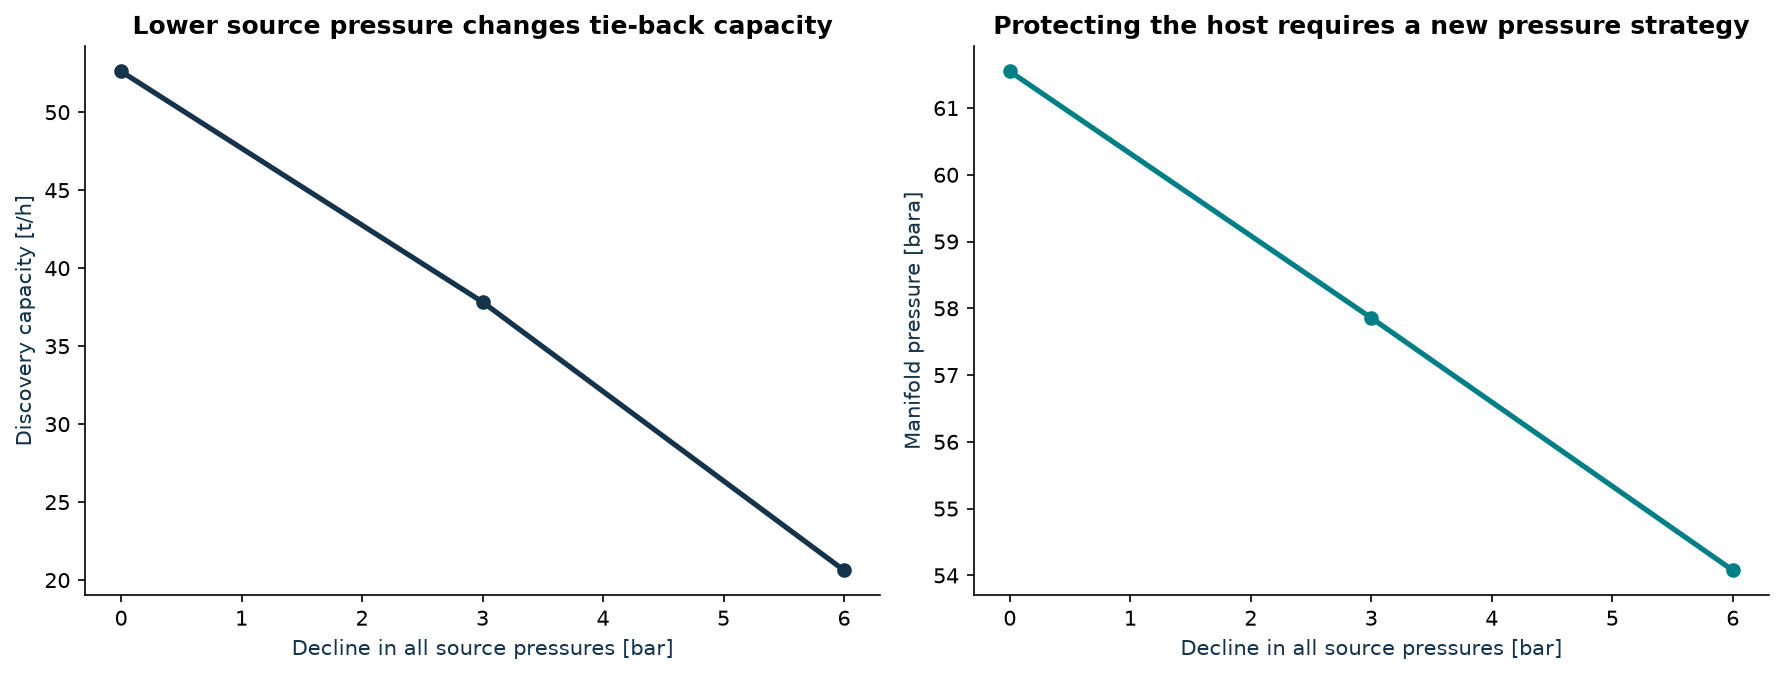

In [26]:
pressure_life = []
for pressure_drop in [0.0, 3.0, 6.0]:
    stale = evaluate(
        controls(derated), derating=0.85, source_pressure_drop=pressure_drop, fresh=True
    )
    revised = optimize(0.85, source_pressure_drop=pressure_drop)
    pressure_life.append(
        {
            "Source-pressure decline [bar]": pressure_drop,
            "Previous settings feasible": stale["feasible"],
            "Replanned discovery [t/h]": revised["tie_kg_h"] / 1000,
            "Manifold pressure [bara]": revised["pressure_bara"],
            "Replanned feasible": revised["feasible"],
            "Limiting constraint": revised["limiting"],
            "Simulation ID": revised["simulation_id"],
        }
    )
pressure_life = pd.DataFrame(pressure_life)
show_table(pressure_life)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(
    pressure_life["Source-pressure decline [bar]"],
    pressure_life["Replanned discovery [t/h]"],
    "o-",
    linewidth=2.5,
)
axes[0].set(
    xlabel="Decline in all source pressures [bar]",
    ylabel="Discovery capacity [t/h]",
    title="Lower source pressure changes tie-back capacity",
)
axes[1].plot(
    pressure_life["Source-pressure decline [bar]"],
    pressure_life["Manifold pressure [bara]"],
    "o-",
    linewidth=2.5,
    color=COLORS["teal"],
)
axes[1].set(
    xlabel="Decline in all source pressures [bar]",
    ylabel="Manifold pressure [bara]",
    title="Protecting the host requires a new pressure strategy",
)
show_figure(figure, "12b_source_pressure_decline")


## 21 · The agent tools: bounded actions, explicit evidence

An engineering agent should select useful investigations, read their results and revise its
plan. The tools below expose that work directly. They cannot execute arbitrary Python, change
source code, alter protected host production, or write to plant controls.

| Tool | What it does |
|---|---|
| `inspect_asset` | Returns design basis, approved controls, current scenario and discovered variables |
| `evaluate_case` | Runs one bounded four-control case and returns physical and feasibility evidence |
| `optimize_operation` | Invokes the documented multistart optimizer with a requested reserve margin |
| `stress_test` | Evaluates uncertainties around a case produced in this agent session |
| `compare_upgrades` | Runs the three explicitly defined hardware hypotheses |
| `verify_recommendation` | Rebuilds the selected case under the current scenario and blocks an infeasible recommendation |

The scenario is supplied by the user/session context. It is not an argument through which the
agent can remove the derating. Results are keyed by simulation ID and a case must belong to
the current session. A passing session stress test and final fresh verification are mandatory even if a cached result was feasible.

In [27]:
def object_schema(properties):
    return {
        "type": "object",
        "properties": properties,
        "required": list(properties),
        "additionalProperties": False,
    }


number_schema = lambda low, high: {"type": "number", "minimum": low, "maximum": high}
TOOL_SCHEMAS = {
    "inspect_asset": object_schema({}),
    "evaluate_case": object_schema(
        {
            "tie_kg_h": number_schema(0, 60000),
            "pressure_bara": number_schema(48, 64),
            "temperature_C": number_schema(22, 32),
            "split": number_schema(0.35, 0.65),
        }
    ),
    "optimize_operation": object_schema({"reserve_margin": number_schema(0.0, 0.12)}),
    "stress_test": object_schema({"simulation_id": {"type": "string"}}),
    "compare_upgrades": object_schema({}),
    "verify_recommendation": object_schema({"simulation_id": {"type": "string"}}),
}


class AssetAgentSession:
    def __init__(self, derating=0.85, simulation_budget=1800):
        self.derating = derating
        self.simulation_budget = simulation_budget
        self.start_count = COUNT
        self.cases = {}
        self.trace = []
        self.stress_evidence = {}
        self.final = None

    def remember(self, result):
        self.cases[result["simulation_id"]] = result
        return compact(result)

    def call(self, name, arguments):
        global ACTIVE_SIMULATION_LIMIT
        previous_limit = ACTIVE_SIMULATION_LIMIT
        ACTIVE_SIMULATION_LIMIT = self.start_count + self.simulation_budget
        started = time.perf_counter()
        before = COUNT
        try:
            if name not in TOOL_SCHEMAS:
                raise ValueError("Unknown tool.")
            jsonschema.validate(arguments, TOOL_SCHEMAS[name])
            if any(
                isinstance(value, float) and not math.isfinite(value)
                for value in arguments.values()
            ):
                raise ValueError("Non-finite arguments.")
            if COUNT - self.start_count >= self.simulation_budget:
                raise RuntimeError("Simulation budget reached; inspect existing evidence.")
            if name == "inspect_asset":
                output = {
                    "protected_host_kg_h": [50000, 30000],
                    "compressor_1_derating": self.derating,
                    "controls": CONTROL_BOUNDS,
                    "export_pressure_bara": 110,
                    "CO2_limit_mol_pct": 3.3,
                    "model": "SRK with fixed synthetic seven-speed compressor maps",
                    "variables_discovered": len(variable_catalog),
                    "qualification": "Host screening; downstream and dynamic studies open",
                }
            elif name == "evaluate_case":
                vector = [
                    arguments[k]
                    for k in ["tie_kg_h", "pressure_bara", "temperature_C", "split"]
                ]
                result = evaluate(vector, derating=self.derating, fresh=True)
                output = self.remember(result)
                output["violated_constraints"] = {
                    k: v for k, v in result["margins"].items() if v < -1e-7
                }
            elif name == "optimize_operation":
                result = optimize(self.derating, margin=arguments["reserve_margin"])
                output = self.remember(result)
                output["optimizer_success"] = result["optimizer_success"]
                output["optimizer_message"] = result["optimizer_message"]
            elif name == "compare_upgrades":
                output = {
                    package: self.remember(optimize(self.derating, package))
                    for package in ["driver", "cooler", "combined"]
                }
            elif name == "stress_test":
                result = self.cases[arguments["simulation_id"]]
                frame = stress_case(result, size=48, seed=191)
                output = {
                    "simulation_id": result["simulation_id"],
                    "passed": int(frame.feasible.sum()),
                    "tested": len(frame),
                    "minimum_driver_margin": float(frame.minimum_driver_margin.min()),
                    "minimum_CO2_margin": float(frame.CO2_margin.min()),
                }
                self.stress_evidence[result["simulation_id"]] = output
            else:
                previous = self.cases[arguments["simulation_id"]]
                stress = self.stress_evidence.get(arguments["simulation_id"])
                if not stress or stress["passed"] != stress["tested"]:
                    raise ValueError(
                        "A fully passing session stress test is required before recommendation."
                    )
                result = evaluate(
                    controls(previous),
                    derating=self.derating,
                    upgrade=previous["upgrade"],
                    fresh=True,
                )
                if not result["feasible"]:
                    raise ValueError("Fresh verification rejected this recommendation.")
                output = self.remember(result)
                output["audit"] = {
                    k: result[k] for k in ["mass_error", "component_error", "energy_error"]
                }
                output["qualification"] = "Verified host screening; engineering review required"
                self.final = output
        except Exception as error:
            # Boundary failure is explicit and cannot turn into a feasible recommendation.
            output = {
                "error": type(error).__name__,
                "message": str(error)[:350],
                "accepted": False,
            }
        ACTIVE_SIMULATION_LIMIT = previous_limit
        self.trace.append(
            {
                "tool": name,
                "arguments": arguments,
                "output": output,
                "seconds": time.perf_counter() - started,
                "simulations": COUNT - before,
            }
        )
        return output


## 22 · Executed replay: an agent investigation you can audit

This is a **deterministic replay of the investigation plan selected by the Codex assistant
during development**, using newly executed tools and freshly calculated results. It is not
presented as a recorded live OpenAI API transcript or as proof of autonomous generalization.

The replay makes the decision path reproducible without credentials: inspect the asset,
challenge the old recommendation under derating, optimize, test uncertainty, reserve margin,
retest, investigate hardware alternatives, and verify a final operating proposal. The next
section contains the actual live language-model loop, which may choose a different sequence.

In [28]:
replay = AssetAgentSession(derating=0.85)
replay.call("inspect_asset", {})
replay.call(
    "evaluate_case",
    dict(zip(["tie_kg_h", "pressure_bara", "temperature_C", "split"], controls(nominal))),
)
replay_nominal = replay.call("optimize_operation", {"reserve_margin": 0.0})
replay.call("stress_test", {"simulation_id": replay_nominal["simulation_id"]})
replay_margin = replay.call("optimize_operation", {"reserve_margin": 0.08})
replay_stress = replay.call("stress_test", {"simulation_id": replay_margin["simulation_id"]})
replay.call("compare_upgrades", {})
replay_final = replay.call(
    "verify_recommendation", {"simulation_id": replay_margin["simulation_id"]}
)
assert replay.final is not None
trace_table = pd.DataFrame(
    [
        {
            "Step": i + 1,
            "Tool": entry["tool"],
            "Simulations": entry["simulations"],
            "Seconds": entry["seconds"],
            "Result": json.dumps(entry["output"], default=float),
        }
        for i, entry in enumerate(replay.trace)
    ]
)
show_table(trace_table[["Step", "Tool", "Simulations", "Seconds"]])
for index, entry in enumerate(replay.trace):
    print(f"Step {index+1}: {entry['tool']}")
    print(json.dumps(entry["output"], indent=2, default=float))


Step 1: inspect_asset
{
  "protected_host_kg_h": [
    50000,
    30000
  ],
  "compressor_1_derating": 0.85,
  "controls": [
    [
      0.0,
      60000.0
    ],
    [
      48.0,
      64.0
    ],
    [
      22.0,
      32.0
    ],
    [
      0.35,
      0.65
    ]
  ],
  "export_pressure_bara": 110,
  "CO2_limit_mol_pct": 3.3,
  "model": "SRK with fixed synthetic seven-speed compressor maps",
  "variables_discovered": 153,
  "qualification": "Host screening; downstream and dynamic studies open"
}
Step 2: evaluate_case
{
  "simulation_id": "SIM-01644",
  "tie_kg_h": 60000.0,
  "pressure_bara": 61.54888549862176,
  "temperature_C": 23.662259864833047,
  "split": 0.49999999998965894,
  "power_kW": 2899.573624956889,
  "cooling_kW": 6093.364440803691,
  "gas_kg_h": 135399.6224294716,
  "liquid_kg_h": 4600.377570528284,
  "co2_mol_pct": 3.2321354709265573,
  "wobbe_MJ_Sm3": 52.23618949284453,
  "feasible": false,
  "limiting": "driver_1",
  "violated_constraints": {
    "driver_1": -0

Step,Tool,Simulations,Seconds
1,inspect_asset,0,0.001
2,evaluate_case,1,0.176
3,optimize_operation,2,0.107
4,stress_test,48,3.885
5,optimize_operation,2,0.208
6,stress_test,48,3.701
7,compare_upgrades,6,0.537
8,verify_recommendation,1,0.061


## 23 · Optional live language-model agent

Set `RUN_LIVE_AGENT = True`, supply `OPENAI_API_KEY` through a Colab secret or environment
variable, and choose a model available to your account. The adapter uses the documented
Responses function-calling interface. Tool calls are validated and executed locally; returned
outputs are sent back to the model. The API receives the synthetic asset description and
calculated summaries. Never put a credential in a notebook cell or retained output.

The code does not substitute a scripted response when the API is unavailable. The retained
default execution reports **live API not run**. That distinction matters when demonstrating
agent performance to an industrial audience. A successful replay validates the tools, not the
quality, reliability or latency of an unexecuted live language model.

The model cannot change the protected production or derating. It must call
`verify_recommendation` to produce an accepted numerical proposal. Free-text output alone is
never treated as a verified engineering recommendation.

In [29]:
RUN_LIVE_AGENT = False
LIVE_MODEL = os.environ.get("OPENAI_MODEL", "gpt-6-astra")
USER_OBJECTIVE = (
    "Compressor 1 has 15% less driver power. Preserve Host A and B production. "
    "Investigate the 60 t/h discovery nomination, test uncertainty, and recommend a "
    "feasible operating case with margin. Compare upgrades if they restore the nomination."
)
TOOL_DESCRIPTIONS = {
    "inspect_asset": "Inspect protected production, current scenario and reviewed controls.",
    "evaluate_case": "Run one full NeqSim case; inspect violated constraints before recommending.",
    "optimize_operation": "Maximize discovery rate with specified reserve margin using SLSQP.",
    "stress_test": "Challenge a session case with 48 full-process uncertain realizations.",
    "compare_upgrades": "Compare three approved hardware packages under the current derating.",
    "verify_recommendation": "Rebuild and verify a case; required for final acceptance.",
}


def run_live_agent(api_key, model, objective, max_turns=16):
    # Standard-library HTTP keeps the optional adapter independent of SDK version changes.
    import urllib.request

    session = AssetAgentSession(0.85)
    conversation = [{"role": "user", "content": objective}]
    descriptions = [
        {
            "type": "function",
            "name": name,
            "description": TOOL_DESCRIPTIONS[name],
            "parameters": schema,
            "strict": True,
        }
        for name, schema in TOOL_SCHEMAS.items()
    ]
    instructions = (
        "You are an engineering study planner using a synthetic NeqSim host model. "
        "Use tools for every numerical claim. Inspect the asset first. Keep both host feeds fixed. "
        "Compare original settings and reoptimization. Test uncertainty before recommending. "
        "If the nominal optimum fails stress tests, request reserve margin and retest. "
        "A final recommendation requires verify_recommendation. Report model boundaries and "
        "remaining shortfall. Do not claim global optimality or plant approval."
    )
    usage_records = []
    narrative = []
    for turn in range(max_turns):
        payload = {
            "model": model,
            "instructions": instructions,
            "input": conversation,
            "tools": descriptions,
            "parallel_tool_calls": False,
            "store": False,
            "include": ["reasoning.encrypted_content"],
            "max_output_tokens": 4000,
        }
        request = urllib.request.Request(
            "https://api.openai.com/v1/responses",
            data=json.dumps(payload).encode(),
            headers={"Authorization": "Bearer " + api_key, "Content-Type": "application/json"},
        )
        with urllib.request.urlopen(request, timeout=180) as response:
            reply = json.load(response)
        usage_records.append(reply.get("usage", {}))
        output = reply.get("output", [])
        conversation.extend(output)
        calls = [item for item in output if item.get("type") == "function_call"]
        for item in output:
            if item.get("type") == "message":
                narrative.extend(
                    part.get("text", "")
                    for part in item.get("content", [])
                    if part.get("type") == "output_text"
                )
        for call in calls:
            try:
                arguments = json.loads(call["arguments"])
                result = session.call(call["name"], arguments)
            except (ValueError, TypeError) as error:
                result = {"error": type(error).__name__, "accepted": False}
            conversation.append(
                {
                    "type": "function_call_output",
                    "call_id": call["call_id"],
                    "output": json.dumps(result, default=float),
                }
            )
        if not calls:
            break
    return {
        "verified_recommendation": session.final,
        "tool_trace": session.trace,
        "narrative": narrative,
        "usage": usage_records,
        "status": "verified" if session.final else "no_verified_recommendation",
    }


live_result = {"status": "not_run", "reason": "Default credential-free replay mode."}
if RUN_LIVE_AGENT:
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        try:
            from google.colab import userdata
        except ImportError:
            userdata = None
        if userdata is not None:
            api_key = userdata.get("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError(
            "Live mode requires an API key; no scripted fallback is substituted."
        )
    live_result = run_live_agent(api_key, LIVE_MODEL, USER_OBJECTIVE)
    api_key = None
print("Live API status:", live_result["status"])
if RUN_LIVE_AGENT:
    print(json.dumps(live_result, indent=2, default=float))


Live API status: not_run


## 24 · Deliberately challenge the tool boundary

These checks exercise failure cases that matter: an unknown tool, an out-of-range pressure,
an attempt to change protected host production, a non-finite control and an invented result ID.
They must not execute a simulation or produce a verified recommendation. A valid engineering
candidate is checked independently afterwards. These are local tool-contract tests; the optional
HTTP adapter has not been validated against a live API in the retained run.

In [30]:
guard_session = AssetAgentSession()
before_guards = COUNT
guard_cases = [
    ("execute_python", {"code": "change the plant"}),
    (
        "evaluate_case",
        {"tie_kg_h": 60000, "pressure_bara": 500, "temperature_C": 25, "split": 0.5},
    ),
    (
        "evaluate_case",
        {
            "tie_kg_h": 30000,
            "pressure_bara": 55,
            "temperature_C": 25,
            "split": 0.5,
            "host_A_kg_h": 0,
        },
    ),
    (
        "evaluate_case",
        {"tie_kg_h": float("nan"), "pressure_bara": 55, "temperature_C": 25, "split": 0.5},
    ),
    ("verify_recommendation", {"simulation_id": "invented-result"}),
]
guard_rows = []
for name, arguments in guard_cases:
    output = guard_session.call(name, arguments)
    assert output.get("accepted") is False
    guard_rows.append({"Tool": name, "Rejected": True, "Reason": output["error"]})
guard_simulations = COUNT - before_guards
assert guard_simulations == 0
assert guard_session.final is None
show_table(pd.DataFrame(guard_rows))


Tool,Rejected,Reason
execute_python,True,ValueError
evaluate_case,True,ValidationError
evaluate_case,True,ValidationError
evaluate_case,True,ValueError
verify_recommendation,True,KeyError


## 25 · Compare baseline, optimizer and agent investigation fairly

The baseline uses original settings. The optimizer solves the nominal derated maximum-rate
problem. The replayed agent investigation additionally asks for margin and tests uncertainty.
It deliberately accepts less throughput to improve the sampled operating margins. These are
different decision policies, so the table is not an AI-versus-optimizer speed or intelligence
leaderboard. The agent uses the same optimizer as one of its tools.

Recorded simulation counts separate cache hits from newly executed physical cases. Replay
latency excludes language-model inference and cannot predict live API cost or latency. A fair
future agent benchmark should use unseen disturbances, identical tool budgets and independent
feasibility tests for every policy.

In [31]:
stress_fixed = stress_case(fixed_derated, size=96, seed=718)
policy_comparison = pd.DataFrame(
    [
        {
            "Policy": "Original controls / derated",
            "Discovery [t/h]": fixed_derated["tie_kg_h"] / 1000,
            "Power [MW]": fixed_derated["power_kW"] / 1000,
            "Feasible": fixed_derated["feasible"],
            "Stress evidence": f"{int(stress_fixed.feasible.sum())}/{len(stress_fixed)} passed",
        },
        {
            "Policy": "Nominal numerical optimization",
            "Discovery [t/h]": derated["tie_kg_h"] / 1000,
            "Power [MW]": derated["power_kW"] / 1000,
            "Feasible": derated["feasible"],
            "Stress evidence": f"{int(stress_nominal.feasible.sum())}/{len(stress_nominal)} passed",
        },
        {
            "Policy": "Agent-plan replay / margin",
            "Discovery [t/h]": replay_final["tie_kg_h"] / 1000,
            "Power [MW]": replay_final["power_kW"] / 1000,
            "Feasible": replay_final["feasible"],
            "Stress evidence": f"{replay_stress['passed']}/{replay_stress['tested']} passed",
        },
    ]
)
show_table(policy_comparison)
show_table(
    pd.DataFrame(
        [
            {"Run": "Nominal optimizer", **nominal_metrics},
            {"Run": "Derated optimizer", **derated_metrics},
            {
                "Run": "Agent-plan replay tools",
                "seconds": sum(r["seconds"] for r in replay.trace),
                "simulations": sum(r["simulations"] for r in replay.trace),
            },
        ]
    )
)


Policy,Discovery [t/h],Power [MW],Feasible,Stress evidence
Original controls / derated,6.067,2.465,True,40/96 passed
Nominal numerical optimization,52.618,2.683,True,2/96 passed
Agent-plan replay / margin,42.912,2.468,True,48/48 passed


Run,seconds,simulations
Nominal optimizer,7.338,102
Derated optimizer,9.555,117
Agent-plan replay tools,8.676,108


## 26 · Fresh reconstruction, order independence and final validation

We rebuild the selected case after the unrelated sweeps and economics runs. Its physical
results must agree with the earlier case. This protects against stale Java state and mutable
compressor-map reuse. We also check the full evaluated history for finite, conservative
results, while retaining rejected operating cases as evidence.

The evidence ladder reached here is conservation, a broad independent ideal-gas screen,
EOS sensitivity and local/grid numerical checks. There is no vendor-map or experimental
plant benchmark. The notebook is a reproducible engineering demonstrator, not an approved
operating procedure.

In [32]:
fresh = evaluate(controls(robust), derating=0.85, fresh=True)
checks = {
    "protected host feeds": all(
        abs(r["host_A_kg_h"] - 50000.0) < 1e-6 and abs(r["host_B_kg_h"] - 30000.0) < 1e-6
        for r in HISTORY
    ),
    "nominal recommendation feasible": nominal["feasible"],
    "old recommendation rejected after derating": not old_under_derating["feasible"],
    "derated replan feasible": derated["feasible"],
    "margin candidate feasible": fresh["feasible"],
    "margin holdout fully passes": bool(holdout_robust.feasible.all()),
    "pressure-decline replans feasible": bool(pressure_life["Replanned feasible"].all()),
    "mass closure every process": max(r["mass_error"] for r in HISTORY) < 1e-6,
    "component closure every process": max(r["component_error"] for r in HISTORY) < 1e-6,
    "enthalpy closure every process": max(r["energy_error"] for r in HISTORY) < 1e-5,
    "fresh power repeatability": np.isclose(fresh["power_kW"], robust["power_kW"], rtol=1e-7),
    "fresh liquid repeatability": np.isclose(
        fresh["liquid_kg_h"], robust["liquid_kg_h"], rtol=1e-7
    ),
    "replay final verification": replay.final is not None,
    "malformed calls did not simulate": guard_simulations == 0,
    "resource scenarios conserve resource": bool(
        (economic_uncertainty.produced_Mt <= economic_uncertainty.resource_Mt + 1e-9).all()
    ),
}
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
show_table(
    pd.DataFrame([{"Check": name, "Passed": bool(passed)} for name, passed in checks.items()])
)
validation = {
    "checks": {key: bool(value) for key, value in checks.items()},
    "simulations": COUNT,
    "stored_operating_rejections": sum(not r["feasible"] for r in HISTORY),
    "maximum_mass_error": max(r["mass_error"] for r in HISTORY),
    "maximum_component_error": max(r["component_error"] for r in HISTORY),
    "maximum_energy_error": max(r["energy_error"] for r in HISTORY),
    "holdout_passed": int(holdout_robust.feasible.sum()),
    "holdout_cases": len(holdout_robust),
    "live_api_status": live_result["status"],
}
print(json.dumps(validation, indent=2))


{
  "checks": {
    "protected host feeds": true,
    "nominal recommendation feasible": true,
    "old recommendation rejected after derating": true,
    "derated replan feasible": true,
    "margin candidate feasible": true,
    "margin holdout fully passes": true,
    "pressure-decline replans feasible": true,
    "mass closure every process": true,
    "component closure every process": true,
    "enthalpy closure every process": true,
    "fresh power repeatability": true,
    "fresh liquid repeatability": true,
    "replay final verification": true,
    "malformed calls did not simulate": true,
    "resource scenarios conserve resource": true
  },
  "simulations": 1848,
  "stored_operating_rejections": 871,
  "maximum_mass_error": 1.4795666835817146e-15,
  "maximum_component_error": 3.62482569035995e-15,
  "maximum_energy_error": 1.490032129442962e-10,
  "holdout_passed": 96,
  "holdout_cases": 96,
  "live_api_status": "not_run"
}


Check,Passed
protected host feeds,True
nominal recommendation feasible,True
old recommendation rejected after derating,True
derated replan feasible,True
margin candidate feasible,True
margin holdout fully passes,True
pressure-decline replans feasible,True
mass closure every process,True
component closure every process,True
enthalpy closure every process,True


## 27 · The engineering decision brief

The brief below is assembled from verified result objects. No numerical value is supplied by
a language-model completion. The host-feasibility qualification stays separate from downstream
flow assurance, detailed equipment design and dynamic operating acceptance.

In [33]:
decision = {
    "question": "Accept the discovery while protecting 80 t/h host production?",
    "nominal_accepted_tie_t_h": nominal["tie_kg_h"] / 1000,
    "derated_original_settings_t_h": fixed_derated["tie_kg_h"] / 1000,
    "derated_maximum_screened_t_h": derated["tie_kg_h"] / 1000,
    "derated_margin_candidate_t_h": fresh["tie_kg_h"] / 1000,
    "margin_candidate_controls": compact(fresh),
    "holdout_pass_fraction": float(holdout_robust.feasible.mean()),
    "nomination_shortfall_t_h": (60000 - fresh["tie_kg_h"]) / 1000,
    "driver_package_nominal_t_h": upgrades["driver"]["tie_kg_h"] / 1000,
    "economic_scenario_npv_MEUR": economic_results["8% margin"]["npv_MEUR"],
    "qualification": "Synthetic host-capacity screening; no plant operating approval",
    "open_engineering_actions": [
        "Replace synthetic maps and limits with vendor-qualified equipment evidence.",
        "Replace reduced deliverability with reservoir, well and SURF calculations.",
        "Qualify downstream condensation, dehydration, water/hydrate and export specifications.",
        "Run transient controls and anti-surge studies before defining an operating transition.",
        "Validate cooling utility approach, hydraulics, fouling and off-design performance.",
        "Replace commercial assumptions with project estimates and fiscal/economic models.",
    ],
}
display(HTML(f"""<div style='border-left:6px solid #007F86;background:#EDF6F5;padding:24px'>
<h2>Decision for the synthetic host</h2>
<p style='font-size:20px'><b>{decision['derated_margin_candidate_t_h']:.1f} t/h</b>
discovery feed with reserved margin after the driver derating.</p>
<p>Both existing fields remain at <b>80.0 t/h combined</b>.
The nominal derated maximum is {decision['derated_maximum_screened_t_h']:.1f} t/h.</p>
<p>Independent holdout: <b>{validation['holdout_passed']}/{validation['holdout_cases']}</b>
cases pass the defined host screens. This is conditional scenario evidence.</p>
<p>Pressure {fresh['pressure_bara']:.2f} bara · separator {fresh['temperature_C']:.2f} °C ·
Train 1 allocation {fresh['split']*100:.1f}% · shaft power {fresh['power_kW']/1000:.2f} MW.</p>
<p><b>Qualification:</b> engineering demonstrator;
downstream and dynamic acceptance remain open.</p>
</div>"""))
print(json.dumps(decision, indent=2))


{
  "question": "Accept the discovery while protecting 80 t/h host production?",
  "nominal_accepted_tie_t_h": 60.0,
  "derated_original_settings_t_h": 6.0671234130859375,
  "derated_maximum_screened_t_h": 52.617810581951105,
  "derated_margin_candidate_t_h": 42.91154906169144,
  "margin_candidate_controls": {
    "simulation_id": "SIM-01848",
    "tie_kg_h": 42911.54906169144,
    "pressure_bara": 61.54888549862234,
    "temperature_C": 22.0,
    "split": 0.4640055207721075,
    "power_kW": 2467.900008946506,
    "cooling_kW": 5314.822340785109,
    "gas_kg_h": 118668.21069837571,
    "liquid_kg_h": 4243.338363315701,
    "co2_mol_pct": 2.93551436503273,
    "wobbe_MJ_Sm3": 52.3320530906568,
    "feasible": true,
    "limiting": "deliverability_B"
  },
  "holdout_pass_fraction": 1.0,
  "nomination_shortfall_t_h": 17.08845093830856,
  "driver_package_nominal_t_h": 60.0,
  "economic_scenario_npv_MEUR": 340.16918007515017,
  "qualification": "Synthetic host-capacity screening; no plant o

## 28 · Reusable study package and evidence trail

The single notebook contains all model, analysis and agent code, plus its retained results.
The optional exports below make the same evidence easier to reuse: case inputs and versions,
every process evaluation, agent tool trace, uncertainty tables, economics, map arrays, figures
and a decision JSON. They are generated by this notebook; no sibling helper notebook is needed.

The trace records tool names, arguments, results and timing. It records public decision
evidence, not private model reasoning. Credentials and API authorization headers are never
written to the package.

In [34]:
bundle = {
    "provenance": PROVENANCE,
    "decision": decision,
    "validation": validation,
    "economics_assumptions": ECONOMICS,
    "controls": CONTROL_BOUNDS,
    "components": COMPONENTS,
    "compositions": COMPOSITIONS,
    "replay_trace": replay.trace,
    "live_api_status": live_result["status"],
}
(OUTPUT / "results.json").write_text(json.dumps(bundle, indent=2, default=float))
(OUTPUT / "simulation_history.json").write_text(json.dumps(HISTORY, default=float))
for name, frame in [
    ("compressor_maps", map_frame),
    ("operating_envelope", envelope_frame),
    ("uncertainty_nominal", stress_nominal),
    ("uncertainty_margin", stress_robust),
    ("uncertainty_holdout", holdout_robust),
    ("economics_uncertainty", economic_uncertainty),
    ("export_phase_screen", flash_frame),
    ("source_pressure_decline", pressure_life),
    ("agent_tool_trace", trace_table),
]:
    frame.to_csv(OUTPUT / (name + ".csv"), index=False)
manifest = [
    {
        "file": path.name,
        "bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    }
    for path in sorted(OUTPUT.iterdir())
    if path.is_file() and path.name != "manifest.json"
]
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
archive = shutil.make_archive("asset_team_study", "zip", OUTPUT)
show_table(pd.DataFrame(manifest)[["file", "bytes"]])
print("Evidence archive:", archive)
print("Complete NeqSim process simulations:", COUNT)
print("Static scientific figures:", len(FIGURES))


Evidence archive: /workspace/scratch/2a5d9ded405b/asset_team_study.zip
Complete NeqSim process simulations: 1848
Static scientific figures: 14


file,bytes
01_feed_composition.png,41957
02_compressor_maps.png,251734
03_asset_flowsheet.png,85051
04_fixed_settings_capacity.png,123372
05_operating_envelope.png,80207
05b_sampled_tradeoff.png,76948
06_derating_and_replanning.png,71942
07_uncertainty_challenge.png,89174
08_upgrade_screen.png,39578
09_enthalpy_accounting.png,38153


## 29 · What this workflow changes for an industrial team

An asset engineer can start from a decision rather than a long list of manually configured
cases. The agent can inspect a model, discover which constraint matters, choose additional
calculations and rebuild the recommendation when the operating situation changes. The
engineering team can inspect every simulation, modify the assumptions and reproduce the study.

The strongest application is a study assistant connected to governed models and trusted data:
an operator asks about a derating; a production technologist updates deliverability; a process
engineer supplies a compressor map; a project engineer evaluates a modification. Each discipline
contributes evidence through the same explicit case and result contracts.

This notebook intentionally gives the numerical tools authority over feasibility. A language
model may choose a poor investigation or misunderstand a result; the audit trail and final
verification make those errors visible. Production deployment would additionally require
asset-specific model validation, authenticated data access, uncertainty calibration, controlled
change workflows and accountable engineering review.

### Extend the same notebook

1. Replace synthetic feed characterization with measured PVT and uncertainties.
2. Import vendor maps and train-specific mechanical/driver limits.
3. Connect the reduced deliverability relation to the book's reservoir, wells and SURF examples.
4. Add a pressure-drop and temperature model for the tie-back and export pipeline.
5. Test compressor trips, recycle valves and anti-surge controls with a qualified transient model.
6. Compare several live models on unseen disturbances using identical tool budgets and holdout cases.
7. Connect approved mechanical-design results to the 3D workflow once an upgrade concept is selected.

### Connections in the example book

- [Agent-facing process automation](../process/process_automation_api_demo.ipynb)
- [Compressor capacity and field-life debottlenecking](../process/neqsim_compressor_capacity_bottleneck_optimization.ipynb)
- [External nonlinear optimization](../process/external_nonlinear_process_optimization.ipynb)
- [Data reconciliation and Bayesian digital twin](../process/data_reconciliation_bayesian_digital_twin.ipynb)
- [NCS tie-in from reservoir to market](../fielddevelopment/ncs_tie_in_quality_tariff_tax.ipynb)
- [Mechanical design to interactive 3D](../process/mechanical_design_to_3d_models.ipynb)
- [Complete oil and gas value chain](../valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)

### Primary implementation references

- [NeqSim source snapshot used here](https://github.com/equinor/neqsim/tree/5eb26ebad6e180b3756248237ecc33129ec071f4)
- [CompressorChartGenerator source](https://github.com/equinor/neqsim/blob/5eb26ebad6e180b3756248237ecc33129ec071f4/src/main/java/neqsim/process/equipment/compressor/CompressorChartGenerator.java)
- [Compressor operating-point evidence](https://github.com/equinor/neqsim/blob/5eb26ebad6e180b3756248237ecc33129ec071f4/src/main/java/neqsim/process/equipment/compressor/CompressorOperatingPointResult.java)
- [ISO 6976 implementation](https://github.com/equinor/neqsim/blob/5eb26ebad6e180b3756248237ecc33129ec071f4/src/main/java/neqsim/standards/gasquality/Standard_ISO6976.java)
- [SciPy SLSQP](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html)
- [SciPy Latin-hypercube sampling](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.LatinHypercube.html)
- [OpenAI Responses function calling](https://developers.openai.com/api/docs/guides/function-calling)

Source code and tool documentation establish API provenance; they do not qualify the synthetic
asset, assumed well relation, compressor maps, prices or equipment limits against field data.
No distinct NeqSim library defect was established while constructing this study. No library
issue is invented to represent a modelling assumption or an optional live-API limitation.